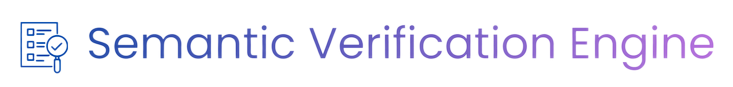

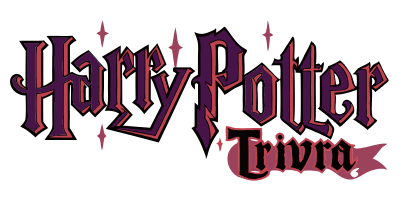

<div style="background-color: #f0e6f7; padding: 10px;">
    <h3 style="text-align:center; color:purple;">Phase 2: NLP Lab (answer checking logic) </h3>
</div>

# A: Introduction

This is a **Semantic Verification Engine (SVE)** currently demonstrated through a *Harry Potter trivia game* 🪄. It demonstrates AI system design where **correctness, latency, and cost predictability** are the key drivers (e.g. medical Q&A, compliance training, or certification exams). 

Traditional trivia engines rely on brittle exact-match strings (e.g. answer == "Severus Snape"). A semantic evaluator is required To allow for natural human variation, spelling errors, and multi-clause explanatory answers. This notebook documents the prototyping, testing, and optimization of hybrid Natural Language Processing (NLP) engines designed to evaluate open-ended user trivia answers. 

The main workflow of this notebook is as follows:

1. [**Addtion of Descriptive Features**](#1-addition-of-descriptive-features-to-gold-dataset) to the gold dataset with script  to support answer checking. Metrics added:
    - 1.1. [*Length Metrics*](#11-length-metrics): question and answer lengths
    - 1.2. [*Answer Types*](#12-answer-types): answers categorized as *text, numeric, date, year* types.
    - 1.3. [*Interrogative Keyword*](#13-interrogative-main-keyword): categoraize questions by the main interrogative keyword.
    - 1.4. [*Status dashboard of Tracer Gold dataset*](#14-dashboard-of-gold-tracer-v1-dataset): provides summary statistics of dataset.

2. [**Game runtime considerations**](#2-game-runtime-considerations): key points to consider when implementing evaluators at runtime.

3. [**Development of semantic evaluator engines**](#3-development-of-semantic-evaluator-engines): individual answer checking logic for each question type:<br>
    - 3.1. [*Runtime prepocessing of dataset at game warmup*](#31-runtime-prepocessing-of-dataset-at-game-warmup): upfront processing for efficient game time latency (e.g. onetime tensor calculation of embeddings)
    - 3.2. [*Answer checking routing overview*](#32-answer-checking-flow-path): outline of how the answer evaluator logic will be arranged.
    - 3.3. [*Evaluators for textual answers*](#33-textual-answers)
        - 3.3.1. [Mulitiple Choice Questions (MCQ)](#331-multiple-choice-questions-mcq) (most straight-forward since player has to type one of the options)
        - 3.3.2.[Factual Recall (FR)](#332-factual-recall-fr-questions) (short, 1-3 words answers typically)
        - 3.3.3. [Explanatory (EX)](#333-open-ended-explanatory-ex-questions)  (most comprehensive answer checking)
    - 3.4. [*Evaluators for non-text answers*]()
    - 3.5. [*Full answer evaluator router*]()   

4. [**Future actions**](#4-future-actions)

# B: Setup & Imports

In [1]:
#  STANDARD NOTEBOOK SETUP
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
from typing import List
sys.path.append('..')
# --- Core Libraries ---
import pandas as pd
import math
from sentence_transformers import SentenceTransformer, util
import numpy as np
import torch
import json
from pathlib import Path
import pyarrow as pa
import pyarrow.parquet as pq
from rapidfuzz import fuzz
from IPython.display import display, Markdown
%matplotlib inline

# --- Project-Specific Imports ---
import core.models as pyd
from core.embeddings import get_sbert_model, get_nli_model
import ds_utils.notebook_config as nb_cfg
import ds_utils.tracer_descp_features_v0 as des
import ds_utils.tracer_nlp_lab_v0 as lab
from ds_utils.ds_constants import ANSWER_CATEGORIES, AnswerType, DataTier, QuestionType, QuestionSource

# custom tokenizer from project ds utils
from ds_utils.text_processing import tokenize_text

# --- Common Settings ---
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 20)

✅ Notebook config loaded.


In [2]:
# load the legacy and synthetic tracer datasets
filename = "dataframe_nb7-2_gold_tracer_v1.parquet"
gold_df = pd.read_parquet(nb_cfg.INTERMEDIATE_DATA_DIR / filename, dtype_backend='pyarrow')

In [3]:
# Gold Tracer dataset v1 (legacy + synthetic)
gold_df.info()
print("\n","-"*50,"\n Count of Question Types:\n")
print(gold_df.groupby('question_type', observed=True)['question'].size().reset_index(name="count"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype                                        
---  ------                        --------------  -----                                        
 0   master_id                     139 non-null    string[pyarrow]                              
 1   original_question_id          104 non-null    int64[pyarrow]                               
 2   syn_id                        35 non-null     string[pyarrow]                              
 3   question_source               139 non-null    string[pyarrow]                              
 4   question_type                 139 non-null    string[pyarrow]                              
 5   question                      139 non-null    string[pyarrow]                              
 6   answer                        139 non-null    string[pyarrow]                              
 7   mcq_options      

# 1: Addition of descriptive features to Gold dataset

**Features to add:**

1. **Length Metrics (`question_length`, `answer_length`)**: Word counts for questions and answers providing baseline measures of complexity.
2. **Answer Typing (`answer_type`)**: Classify each answer as text, numeric, date, or year. This allows the answer checker to handle different data formats intelligently (e.g. handling date variations or accepting "fourteen" for "14" from players).
3. **Main interrogative keyword (`main_keyword`)**: used to sub-categorize questions within `question_types` to assess data health (e.g. skewness -> dataset leans towards a specific keyword / question type limits variability and game experience). It can also help with routing logic in the answer grading logic.

In [4]:
# global random state
RANDOM_SEED = 26

# choose a model
model = get_sbert_model()
nli_model = get_nli_model()

# create working copy of tracer df
df = gold_df.copy()

## 1.1: Length metrics
Adding word count columns for the question and its answer.

In [5]:
## Add word counts for question and answer columns
df['question_length'] = des.get_clean_word_counts(df, 'question')
df['answer_length'] = des.get_clean_word_counts(df, 'answer')

## sanity check 1: 
# 1. Type check: Ensure the helper returned integers, not floats or weird objects
assert pd.api.types.is_integer_dtype(df['question_length']), "question_length is not an integer!"
assert pd.api.types.is_integer_dtype(df['answer_length']), "answer_length is not an integer!"

# 2. Null check: Ensure the helper didn't accidentally wipe out data
assert df['question_length'].notna().all(), "Found missing values in question_length!"

# 3. Logic Check: Every question/answer must have at least one word
assert df['question_length'].min() > 0, "Found a question with 0 words!"
assert df['answer_length'].min() > 0, "Found an answer with 0 words!"

# sanity check 2 - visual review
df[['question','question_length','answer','answer_length']].head()

,question,question_length,answer,answer_length
0,Which of these titles or identities has NOT be...,13,spew treasurer,2
1,Which of the following spells is considered on...,25,crucio,1
2,In which of these scenarios would you use the ...,11,whispering in the library without being overheard,7
3,Which one of the following is not a founder of...,11,helena ravenclaw,2
4,Which of these factors does NOT affect Transfi...,8,hue of the object,4


>**Note: NLP tokenization vs. word count**
>
>The `question_length` and `answer_length` features are calculated using a strict regex tokenization approach (`\b\w+\b`) rather than a naive space-delimited string split (`.split()`). This is an **intentional design choice** to prepare the dataset for the downstream NLP routing engine. Advanced ML models treat punctuation boundaries (like hyphens and apostrophes) as distinct tokens. 
>
>**How this affects the counts:**
>* *Standard `.split()`:* `"What is Harry's wand-core?"` $\rightarrow$ **4 words**
>* *Our NLP Helper:* `"What is Harry's wand-core?"` $\rightarrow$ **6 tokens** (`['What', 'is', 'Harry', 's', 'wand', 'core']`)
>
>If you spot-check the data and notice the length columns are slightly higher than a visual word count, **this is not an error.** It accurately reflects the semantic token load of the text, correctly handling possessives (e.g., "Philosopher's") and hyphenated entities (e.g., "advanced-level").
>
>**Occurences within dataset are demonstrated below:**

In [6]:
# create the baseline (naive split)
baseline_lengths = df['question'].apply(lambda x: len(str(x).split()))

# filter the dataframe to show where counts dont match with baseline (naive) count
mismatches = df[df['question_length'] != baseline_lengths]

# display mismatches
display(mismatches[['master_id','question', 'question_length']].head())

,master_id,question,question_length
15,5ljRL2JJ,According to the description from Professor Sl...,17
16,pGFZQDF_,"What are the final, advanced-level exams that ...",20
25,YrHLNT5a,What was the number of the high-security Gring...,17
26,qWMHzSpQ,Albus Dumbledore is famous for discovering how...,13
28,JzJvhttw,"In Harry Potter and the Philosopher's Stone, h...",18


>These counts are correct.
>- **id. pGFZQDF_:** correctly counts "advanced-level" as two words.
>- **id. 5ljRL2JJ**: splits "Slughorn's" at the apostrophe into "Slughorn" and "s" and counts both.

## 1.2: Answer types

Adding the `answer_type` column with four categories:
- text,
- numeric,
- date,
- year

In [7]:
# classify the remaining questions into 'numeric', 'date', 'year', 'text', into a new column 'answer_type' 
# using the custom function from eda_scripts
df['answer_type'] = df.apply(des.classify_answer_type, axis=1)

# convert column to category
df['answer_type'] = pd.Categorical(df['answer_type'], 
                                   categories=ANSWER_CATEGORIES, 
                                   ordered=False)

# sanity check 1: visual review
df[['question_type','question','answer','answer_type']].groupby('answer_type', observed=True).head(2)

,question_type,question,answer,answer_type
0,MCQ,Which of these titles or identities has NOT be...,spew treasurer,text
1,MCQ,Which of the following spells is considered on...,crucio,text
25,MCQ,What was the number of the high-security Gring...,713,numeric
26,MCQ,Albus Dumbledore is famous for discovering how...,12,numeric
65,FR,When was Azkaban Prison established?,1718,year
66,FR,When was the first full description of the gam...,1398,year
70,FR,On what chilling date did baby Harry Potter mi...,"halloween (or october 31st), 1981",date
71,FR,What day did James and Lily Potter die?,october 31,date


In [8]:
# sanity checks 2:
expected_answer_types = set(ANSWER_CATEGORIES)

# null check
assert df['answer_type'].notna().all(), "CRITICAL: Found Null (NaN) values in answer_type"
# type check: Ensure the column is strictly text/strings
assert pd.api.types.is_string_dtype(df['answer_type']), "CRITICAL: answer_type column is not a string type!"
# empty string check
assert (df['answer_type'].str.strip() != "").all(), "CRITICAL: Found empty strings in answer_type!"
# vocab check: Did the script output any unexpected categories or typos?
actual_answer_types = set(df['answer_type'].unique())
unrecognized_types = actual_answer_types - expected_answer_types
assert not unrecognized_types, f"CRITICAL: Found unexpected answer types: {unrecognized_types}"

print("Answer Type sanity checks passed: Categories are valid, complete, and strictly enforced.")

Answer Type sanity checks passed: Categories are valid, complete, and strictly enforced.


## 1.3: Interrogative main keyword

In [9]:
# create temporary token columns to create main_keyword column
df = des.create_token_columns(df, tokenizer=tokenize_text)
df[['master_id','question','answer','question_tokens', 'answer_tokens','combined_unique_tokens']]

,master_id,question,answer,question_tokens,answer_tokens,combined_unique_tokens
0,RrQ-KzTp,Which of these titles or identities has NOT be...,spew treasurer,"[which, title, identity, have, be, hold, harry...","[spew, treasurer]","[which, title, identity, have, be, hold, harry..."
1,mK7xFxiU,Which of the following spells is considered on...,crucio,"[which, following, spell, be, consider, one, t...",[crucio],"[which, following, spell, be, consider, one, t..."
2,Rv-Itd0C,In which of these scenarios would you use the ...,whispering in the library without being overheard,"[which, scenario, would, use, muffliato, charm]","[whisper, library, without, be, overheard]","[which, scenario, would, use, muffliato, charm..."
3,txOZUZVs,Which one of the following is not a founder of...,helena ravenclaw,"[which, one, following, be, founder, hogwarts]","[helena, ravenclaw]","[which, one, following, be, founder, hogwarts,..."
4,6rNntS3I,Which of these factors does NOT affect Transfi...,hue of the object,"[which, factor, do, affect, transfiguration]","[hue, object]","[which, factor, do, affect, transfiguration, h..."
...,...,...,...,...,...,...
134,KLGMCCkE,What crucial secret did Dumbledore reveal to S...,that a fragment of voldemort's soul resided wi...,"[what, crucial, secret, do, dumbledore, reveal...","[fragment, voldemort, soul, reside, within, ha...","[what, crucial, secret, do, dumbledore, reveal..."
135,Y--cqa16,Who carried Colin Creevey's body from the grou...,oliver wood,"[who, carry, colin, creevey, body, ground, bat...","[oliver, wood]","[who, carry, colin, creevey, body, ground, bat..."
136,u77nA0FB,What creature did Harry instruct Neville Longb...,nagini,"[what, creature, do, harry, instruct, neville,...",[nagini],"[what, creature, do, harry, instruct, neville,..."
137,_NlWzmGZ,How did Sirius Black describe the experience o...,quicker and easier than falling asleep,"[how, do, sirius, black, describe, experience,...","[quicker, easy, fall, asleep]","[how, do, sirius, black, describe, experience,..."


In [10]:
# add `main_keyword` column
df['main_keyword'] = df['question_tokens'].apply(des.extract_main_keyword)

#sanity check 1: visual check
df[['master_id','question','answer','question_tokens','main_keyword']].sample(5,random_state=RANDOM_SEED)

,master_id,question,answer,question_tokens,main_keyword
72,8eVyidSE,What is Snape's birthday?,"january 9, 1960","[what, be, snape, birthday]",what
21,NB0toJDa,Which of the following is NOT a form of Transf...,enchantment,"[which, following, be, form, transfiguration]",which
118,kFTWJTxO,Why did Lord Voldemort not recognize the Resur...,voldemort did not value or comprehend the true...,"[why, do, lord, voldemort, recognize, resurrec...",why
101,6ev09EVV,Which of these is not a species of dragon:,finnish flamethrower,"[which, be, specie, dragon]",which
89,ZOkIPD70,Who does Harry live with before going to Hogwa...,"his aunt and uncle, petunia and vernon dursley...","[who, do, harry, live, go, hogwarts]",who


In [11]:
# sanity check 2: No NaN values accidentally created during the feature extraction
assert df['question_length'].notna().all(), "CRITICAL: Missing values in question_length!"
assert df['main_keyword'].notna().all(), "CRITICAL: Missing values in main_keyword!"

## 1.4: Dashboard of Gold Tracer v1 dataset

Full tracer dataset (legacy and synthetic) dashboard provides a summary of key metrics of the validated Gold dataset. The tracer dataset contains strategically sampled legacy dataset (phase 1 cleaned validated HF dataset) and synthetically questions generated by an LLM in the offline *SVE Content Factory*.

## 📊 Trivia Dataset Status Map

---

### 1. Key Metrics

**- Total Unique Questions:** 139<br>**- Answer Type Distribution:** text (119), numeric (10), date (5), year (5)<br>


### 2. Breakdown by Question Type

,Question Count,Percentage (%),Unique Answer Count,Median Q Len,Median A Len,Top Answer Keywords,Top main_keyword,Unassigned Keyword Count
Question Type,,,,,,,,
FR,49,35.3%,49,10.0,2.0,"october (2), 31 (2), potter (2)","what (14), when (10), which (7)",0
EX,45,32.4%,45,17.0,20.0,"voldemort (11), dumbledore (8), harry (6)","why (16), how (13), what (9)",0
MCQ,45,32.4%,45,12.0,2.0,"spew (1), treasurer (1), crucio (1)","which (22), what (13), how (5)",0



Note: FR (Factual Recall), EX (Explanatory), YN (Yes/No or True/False), MCQ (Multiple Choice)



### 3. Visualizations by Question Type

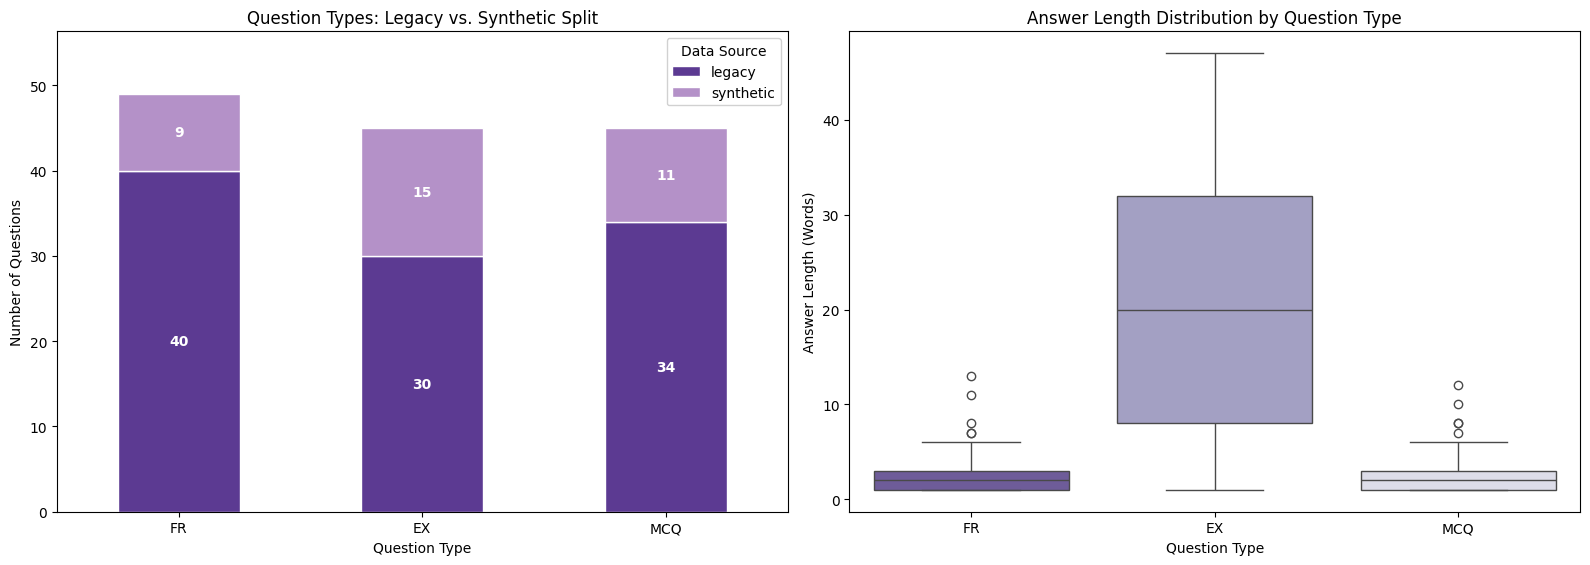


### 📚 Source Text Ingestion Map

,Total_Questions,Chapters_Ingested,Heaviest Chapters (Count)
Book,,,
Legacy Data,104,0,
deathly_hallows,35,6,"Chapter 31 (8), Chapter 35 (8)"



---

In [12]:
des.generate_dataset_status_report(df)

# 2: Game runtime considerations

1. **Data lifecycle: upfront / global warmup**
    - *Logic*: Load the entire dataset (Tracer: ~104 questions; Production: ~1000 to ~6000 questions) from Parquet/Storage into RAM once. For ~6000 questions, the memory required is likely around ~9MB. The heavy part of the warm up will likely be the SBERT model itself (~100MB).
    - *Transformation*: Immediately promote List[float] embeddings to torch.float32 Tensors.
    - *Rational*: Since SBERT is required for player input encoding, the PyTorch library is already a dependency. Utilizing Tensors for the dataset provides preexisting compatibility and fast math operations. It also reduces latency between questions and between sessions by performing the transformation upfront as a batch (full tracer dataset or question bank at produciton level).

2. **State Management: Shuffled Pool Sampling (without replacement from bank)**. To maintain game flow and variety, the game will load a question bank upfront (full tracer or preset size set of e.g. 500 questions) for a given session. 
    - An `available_indices` list will be generated and shuffled at the start of the session.
    - For sampling: questions are popped from the list without replacement ($n=10$ per round, O(1) time efficiency). This guarantees a unique experience across a 10-round session (100 questions).It simplifies state management; the engine doesn't need to track a seen list.

3. **Semantic verification logic (tiered hierarchy)**. Logic follows a hierarchical approach to balance speed and semantic depth for all question types (with variations to adapt to the specifics of each type). Tiers will be adapted to each question type and consist of *exact match, fuzzy match, sbert similarity, NLI (Natural Language Inference), and final resolution with LLM api calls*.  

4. **End of road strategy considerations**. when player has used up all the bank in a session, can consider different options to handle game state:
    1. *Graceful end*: needed with tracer (in case player uses up all ~104 questions). Display a "check back in future" message for expanded or full game.
    2. *Spaced repetition*: A new challenge run made up of all the questions they had gotten wrong in the session and then gracefully end. Useful for other uses cases of the system, e.g. MCAT prep.
    3. *Competitive resuffle*: when Gold dataset is larger than gametime bank (e.g. ~6000 questions). Load a new non-repetitive bank of questions but with increased difficulty / challenge / theme etc.

>**NOTE**: By promoting all 100+ questions (full tracer dataset or question bank for full game) to Tensors at startup, the system optimizes for user flow / experience. Since SBERT will already be loaded for answer checking, the memory cost of 1,000 tensors (~1.6MB) is negligible compared to the benefit of almost instant verification.

# 3: Development of semantic evaluator engines

In [13]:
# answer types
counts = df.groupby('question_type')['answer_type'].value_counts()
pivot = counts.unstack(fill_value=0)
print(pivot)

answer_type    numeric  text  date  year
question_type                           
EX                   0    45     0     0
FR                   5    34     5     5
MCQ                  5    40     0     0


## 3.1: Runtime prepocessing of dataset at game warmup

Add tensors to dataset at containter startup (see [section 4, point 1](#4-game-time-consideration)) for simpler in-game answer evaluation.

In [14]:
df.columns

Index(['master_id', 'original_question_id', 'syn_id', 'question_source',
       'question_type', 'question', 'answer', 'mcq_options',
       'source_reference', 'source_quote', 'hint_1', 'hint_2', 'hint_3',
       'explanation', 'answer_variations', 'semantic_entity_refs',
       'semantic_lore_concepts', 'question_embeddings', 'answer_embeddings',
       'answer_variations_embeddings', 'mcq_distractors_embeddings',
       'source_quote_embeddings', 'question_length', 'answer_length',
       'answer_type', 'question_tokens', 'answer_tokens',
       'combined_unique_tokens', 'main_keyword'],
      dtype='object')

In [15]:
## Add tensors for embedding columns
emb_cols = ['question_embeddings', 'answer_embeddings']
emb_list_cols = ['answer_variations_embeddings', 'mcq_distractors_embeddings']  # 'source_quote_embeddings' not required for game

# Execute tensor method on the tracer df
runtime_df = lab.prepare_runtime_tensors(dataframe=df,
                                     embedding_col_names=emb_cols,
                                     embedding_list_cols_names=emb_list_cols)

# sanity checks
new_cols = [f"{col}_tensor" for col in emb_cols] + [f"{col}_tensor_matrix" for col in emb_list_cols]
assert set(new_cols).issubset(set(runtime_df.columns)), "CRITICAL: Not all tensor columns were created successfully!"
runtime_df[['master_id','question','question_embeddings_tensor','answer_embeddings_tensor',
            'answer_variations_embeddings_tensor_matrix','mcq_distractors_embeddings_tensor_matrix']].head()

,master_id,question,question_embeddings_tensor,answer_embeddings_tensor,answer_variations_embeddings_tensor_matrix,mcq_distractors_embeddings_tensor_matrix
0,RrQ-KzTp,Which of these titles or identities has NOT be...,"[tensor(-0.0692), tensor(0.0238), tensor(0.011...","[tensor(-0.0500), tensor(-0.0012), tensor(-0.0...","[[tensor(-0.0500), tensor(-0.0012), tensor(-0....","[[tensor(-0.0475), tensor(0.0124), tensor(0.03..."
1,mK7xFxiU,Which of the following spells is considered on...,"[tensor(0.0045), tensor(0.0814), tensor(-0.138...","[tensor(-0.0346), tensor(0.0673), tensor(-0.06...","[[tensor(-0.0346), tensor(0.0673), tensor(-0.0...","[[tensor(0.0001), tensor(0.0421), tensor(-0.11..."
2,Rv-Itd0C,In which of these scenarios would you use the ...,"[tensor(-0.0361), tensor(-0.0051), tensor(0.03...","[tensor(-0.0154), tensor(-0.0675), tensor(0.05...","[[tensor(-0.0444), tensor(-0.0519), tensor(0.0...","[[tensor(0.0041), tensor(0.1337), tensor(0.029..."
3,txOZUZVs,Which one of the following is not a founder of...,"[tensor(-2.1572e-05), tensor(0.0080), tensor(-...","[tensor(-0.0344), tensor(-0.0454), tensor(-0.0...","[[tensor(-0.0344), tensor(-0.0454), tensor(-0....","[[tensor(0.0039), tensor(0.0123), tensor(0.017..."
4,6rNntS3I,Which of these factors does NOT affect Transfi...,"[tensor(0.0682), tensor(-0.0122), tensor(-0.00...","[tensor(0.0669), tensor(0.1001), tensor(0.0268...","[[tensor(-0.0157), tensor(0.0926), tensor(-0.0...","[[tensor(0.1058), tensor(-0.0057), tensor(-0.0..."


In [16]:
## sanity checks for tensor conversion
# 1. check simple embeddings (answer_embeddings)
ans_sample = runtime_df['answer_embeddings_tensor'].iloc[0]
assert isinstance(ans_sample, torch.Tensor), "CRITICAL: answer_embeddings_tensor is not a PyTorch Tensor"
assert ans_sample.ndim == 1, f"CRITICAL: answer_embeddings_tensor should be 1D, but got {ans_sample.ndim}D"

# 2. check 2D matrix (mcq_distractors_embeddings)
matrix_sample = runtime_df['mcq_distractors_embeddings_tensor_matrix'].iloc[0]
assert isinstance(matrix_sample, torch.Tensor), "CRITICAL: mcq_distractors_embeddings_tensor_matrix is not a PyTorch Tensor!"
assert matrix_sample.ndim == 2, f"CRITICAL: mcq_distractors_embeddings_tensor_matrix should be 2D, but got {matrix_sample.ndim}D"

## 3.2: Answer checking router overview

Updated through iterative work in developing answer evaluators.

- Future optimization (not needed for tracer): can consider a pre-filter for give-up phrases before evaluating player answer. e.g. if player enters ("i dont know", "idk", "help", "skip", "tell me", "i give up") --> trigger game behaviour like prompt for hints or skip question with penalty etc.

**Initial routing: split by `answer_type`**
- *Path A for Text answers*:  routed directly to the SBERT / NLI evaluators
- *Path B for non-text answers*: `date`, `year`, `numeric` are routed to deterministic evaluators (SBERT is unsuitable for these categories).

**Path A. For `text` answers, route to specific evaluators based on `question_types`**

- *MCQ (Multiple Choice)*: 
1. exact: O(1) fast path for direct string matches.  
2. fuzzy: levenshtein distance check to catch minor typos and spelling errors.
3. semantic resolution: SBERT cosine similarity must meet two conditions
    - (3.1) sbert similarity score against gold answer (or any of the answer variations)is above set *semantic* threshold.
    - (3.2) sufficient margin between (player/gold answer score) and (player ans / closest distractor).

- *FR (Factual Recall)*: 
1. exact 
2. fuzzy 
3. semantic mathc: sbert similarity best match to gold answer /answer variations above semantic threshold 
4. entity boost: If the SBERT score lands in the ambiguous zone, a strict Regex word-boundary check is run against `semantic_entity_refs`. If core proper nouns are found, a boost is added to the baseline score before it is compared to the semantic threshold again. 
5. *Long answers routed evaluated by LLM* to handle vector dilution. This cutoff is based on both player answer (if 2*gold) and gold answer (outlier based on full legacy dataset FR answer length distribution) lengths.

- *EX (Explanatory)*: long open-ended answers (multi-resolution) 
1. fast exact and fuzzy checks can be helpful for the short answers (O(1) deterministic pass assessment)
2. *primary semantic check*: SBERT similarity score of player answer compared against the gold answer and symmetric multi-resolution answer_variations (index 0: full direct, index 1: concise core logic). Scores above the EX *semantic* treshold pass instantly.
3. *Ambiguous score resolution* (below semantic and above ambiguous cutoff treshold): 
    - (3.1) *check coverage*: check presence of terms from the `semantic_entity_refs`, `semantic_lore_concepts`, and `answer_variations` (at index 2: key terms). If required concept coverage falls below the threshold, the answer are failed (preventing wasted compute).
    - (3.2) *NLI judge*: If coverage is sufficient, the player answer (hypothesis) and Gold answer (premise) are evaluated by an NLI Cross-Encoder. `entailment` results in a pass and `neutral`/ `contradiction` results in a fail.
4. *LLM API call* to resolve remaining answers.   

## 3.3: Evaluators for textual answers

### 3.3.1: Multiple choice questions (MCQ)

In [17]:
# filter MCQ questions
mcq_df = runtime_df[runtime_df['question_type']=='MCQ']

# test samples
mcq_sample_df = mcq_df.sample(5, random_state=RANDOM_SEED)

# view samples
display(mcq_sample_df[['master_id', 'question_source','question','mcq_options','answer']])
print(f"types of answers in df: {mcq_sample_df['answer_type'].unique()}")

,master_id,question_source,question,mcq_options,answer
11,RXr8RzpS,legacy,What is the primary effect of Wiggenweld Potion:,['inducing euphoria' 'inducing luck' 'healing ...,healing injuries
9,uVS8WVCo,legacy,Which of these words best describes Slytherin ...,['daring' 'patient' 'resourceful' 'witty'],resourceful
8,V9M7XldD,legacy,which of these plants has healing properties?,"['dittany' 'mandrake' ""devil's snare"" 'wolfsba...",dittany
2,Rv-Itd0C,legacy,In which of these scenarios would you use the ...,['whispering in the library without being over...,whispering in the library without being overheard
5,plVU1ugD,legacy,Which of the following is another dive commonl...,['porskoff ploy' 'bludger backbeat' 'spiral di...,spiral dive


types of answers in df: ['text']
Categories (4, object): ['numeric', 'text', 'date', 'year']


#### A. Unit test using one question

In [18]:
# first split is by `answer_type`: 'text'

# thresholds
FUZZY_THRESHOLD = 85  # 85% character similarity (catches 1-2 letter typos)
SEMANTIC_THRESHOLD = 0.9 # SBERT cosine similarity
DISTRACTOR_DELTA = 0.30 # player answer comparison against distractors vs. correct answer

In [19]:
test_player_answers = {
    'healing injuries': 'correct',      # exact match
    
    'heal injuries': 'correct',         # minor difference (fuzzy should catch this)
    'heeling injuries': 'correct',      # minor typo (fuzzy should catch this)
    'heal injury': 'correct',           # singular vs plural (fuzzy should catch this)
    'injuries healing': 'correct',      # different word order
    'injury healing': 'correct',        # different word order + singular
    'heel injuries': 'incorrect',       # typo plus singular, will also then fail sbert (heel = wrong meaning)
    
    'cure wounds': 'incorrect',           # semantic match (high similarity) but not answer text
    'mend cuts and broken bones': 'incorrect', # semantic match 2 (high similarity) but not answer text
    'restore health': 'incorrect',         # semantic alternative (medium) but not option
    
    'the third one': 'incorrect',       # player referencing position rather than answer
    'inducing luck': 'incorrect',       # picked distractor
    'inducing euphoria': 'incorrect',   # picked distractor
    'shrinking a target': 'incorrect',  # picked distractor,
    'deal with injuries': 'incorrect',  # incomplete answer with correct keyword but missing key concept of "healing"
    'conceal injuries': 'incorrect',    # has correct keyword but wrong action (conceal vs heal)
    'heal pain': 'incorrect',           # has correct keyword but wrong action (heal pain vs heal injuries)
    '': 'incorrect'                     # empty string  
}

# setup 
target_id = 'RXr8RzpS'
question_data = mcq_sample_df[mcq_sample_df['master_id'] == target_id].iloc[0]
gold_answer = question_data['answer']
gold_tensor = question_data['answer_embeddings_tensor']
ans_var_tensor = question_data['answer_variations_embeddings_tensor_matrix']
distractor_tensors = question_data['mcq_distractors_embeddings_tensor_matrix']

assert question_data['answer_type'] == 'text', "CRITICAL: Mismatch in answer type for test question!"
assert question_data['master_id'] == target_id, "CRITICAL: Mismatch in question retrieval logic!"
assert question_data['answer'] == 'healing injuries', "CRITICAL: Mismatch in gold answer retrieval!"

# test mcq text answer logic
i=1
print(f"Testing MCQ answer evaluation logic for question ID: {target_id} | Gold Answer: '{gold_answer}'\n")
for answer, response in test_player_answers.items():
    # check method using helper function from lab module
    result = lab.check_mcq_answer(player_answer=answer,
                              gold_answer=gold_answer,
                              gold_ans_tensor=gold_tensor,
                              answer_variation_tensor_matrix=ans_var_tensor,
                              distractor_tensor_matrix=distractor_tensors,
                              fuzzy_threshold=FUZZY_THRESHOLD,
                              semantic_threshold=SEMANTIC_THRESHOLD,
                              distractor_delta=DISTRACTOR_DELTA)
    # evaluate and display results
    outcome = result.is_correct
    result = "correct" if outcome else "incorrect"
    status = "✅ PASS" if result == response else "❌ FAIL"
    print(f"{i}. {status}: Player answer: '{answer}' --> Expected result: {response} | Actual result: {result}\n")
    i += 1

Testing MCQ answer evaluation logic for question ID: RXr8RzpS | Gold Answer: 'healing injuries'

1. ✅ PASS: Player answer: 'healing injuries' --> Expected result: correct | Actual result: correct

2. ✅ PASS: Player answer: 'heal injuries' --> Expected result: correct | Actual result: correct

3. ❌ FAIL: Player answer: 'heeling injuries' --> Expected result: correct | Actual result: incorrect

4. ✅ PASS: Player answer: 'heal injury' --> Expected result: correct | Actual result: correct

5. ✅ PASS: Player answer: 'injuries healing' --> Expected result: correct | Actual result: correct

6. ✅ PASS: Player answer: 'injury healing' --> Expected result: correct | Actual result: correct

7. ✅ PASS: Player answer: 'heel injuries' --> Expected result: incorrect | Actual result: incorrect

8. ✅ PASS: Player answer: 'cure wounds' --> Expected result: incorrect | Actual result: incorrect

9. ✅ PASS: Player answer: 'mend cuts and broken bones' --> Expected result: incorrect | Actual result: incorrec

#### B. Tracer edge cases 

The following legacy questions were deliberately included in the [Tracer dataset](05_Legacy_dataset_update.ipynb#234-possible-partial-answer--player-shorthand) from th to test the following scenarios: 

|Edge Case Type| `original_question_id` | Test case | Tracer Example|Pass Condition|
|-|-|-|-|-|
|Shorthand |1152|  Horntail → Hungarian Horntail|Can the model map a single-word species name to a multi-word dragon entity?| Answer checker is able to recognize *Horntail* as the key identifier in the options|
|Paraphrase (semantic core)|1361, 1149|Can the model validate a 3-word shorthand against a 15-word longform answer?|*near their house* or *in the park* → *In a park near their homes...*|SBERT captures the core meaning despite word changes|
|Lexical overlap|1163| Can the model identify the answer when all options share a common noun and heavy with domain-specific terms?| *Confundus* (key identifier) or *Confundus spell* (differnt noun) or *Confundo* (spelling error + shorthand) → **confundus charm**| answer checker ignores the redundant *charm* and anchors to the specific spell name|


In [20]:
mcq_edge_cases = [1152, 1361, 1149, 1163]
mcq_edge_cases_df = df[df['original_question_id'].isin(mcq_edge_cases)]
mcq_edge_cases_df[['master_id','original_question_id','question','mcq_options','answer','answer_type','question_type']]

,master_id,original_question_id,question,mcq_options,answer,answer_type,question_type
100,N2M9ajQ1,1149,In which of these scenarios would you use the ...,['mending a broken object' 'summoning an objec...,blasting open a locked trunk,text,MCQ
101,6ev09EVV,1152,Which of these is not a species of dragon:,['hungarian horntail' 'chinese fireball' 'finn...,finnish flamethrower,text,MCQ
102,7Emsqzsr,1163,Which of these is not a type of concealment ch...,['disillusionment charm' 'fidelius charm' 'con...,confundus charm,text,MCQ
103,beSysLQi,1361,When did Lily Evans first meet Severus Snape:,['on the hogwarts express during their first j...,as children in a park near their homes before ...,text,MCQ


In [21]:
test_ec_cases = [
    # Q1149: "blast open locked trunk" (typo & shorthand)
    {'q_id': 1149, 'answer': 'blast open locked truck', 'expected': 'correct'},
    {'q_id': 1149, 'answer': 'blast trunk',             'expected': 'correct'},
    {'q_id': 1149, 'answer': 'blast the trunk',         'expected': 'correct'},

    # Q1152: "Finnish Flamethrower" (shorthand & synonym)
    {'q_id': 1152, 'answer': 'flamethrower',         'expected': 'correct'},
    {'q_id': 1152, 'answer': 'finland flamethrower', 'expected': 'correct'},  
    {'q_id': 1152, 'answer': 'finnish',              'expected': 'correct'},
    {'q_id': 1152, 'answer': 'the finnish one',      'expected': 'correct'},

    # Q1163: "Confundus Charm" (lexical overlap)
    {'q_id': 1163, 'answer': 'confundus',       'expected': 'correct'},
    {'q_id': 1163, 'answer': 'spell',           'expected': 'incorrect'}, # key distingushing term missing
    {'q_id': 1163, 'answer': 'confundus spell', 'expected': 'correct'},  # key term is present / lenient with charm vs spell. Spell umbrella term.
    {'q_id': 1163, 'answer': 'confundus curse', 'expected': 'correct'},  # key term is present / lenient with charm vs curse. sufficient id of correct ans.
    {'q_id': 1163, 'answer': 'confusing spell', 'expected': 'incorrect'},  
    {'q_id': 1163, 'answer': 'confusing charm', 'expected': 'incorrect'},  

    # Q1361: "In a park near their homes" (paraphrase)
    {'q_id': 1361, 'answer': 'in the park',                 'expected': 'correct'},          
    {'q_id': 1361, 'answer': 'as children',                 'expected': 'correct'},          
    {'q_id': 1361, 'answer': 'in the park near their home', 'expected': 'correct'}, 
    {'q_id': 1361, 'answer': 'potions class',               'expected': 'incorrect'}       
]

Iterations: 
1. calculate all tensors upfront in runtime df to avoid heavy compute repetition and simplify answer checking logic.
2. to lower threshold for flexible and more robust checking - use sbert similarity to answer + distance from distractors
3. partial answers are tricky - sbert biased by lenght. Use the 'answer_variations' col for extra validation

In [22]:
core_cols = ['master_id', 'original_question_id', 'syn_id', 'question_source',
       'question_type', 'question', 'answer', 'mcq_options',
        'answer_variations', 'semantic_entity_refs','semantic_lore_concepts']

runtime_df.loc[(runtime_df['question_type']=='MCQ')&
           (runtime_df['answer_type']=='text')&
           (runtime_df['original_question_id'].isin(mcq_edge_cases)),core_cols]

,master_id,original_question_id,syn_id,question_source,question_type,question,answer,mcq_options,answer_variations,semantic_entity_refs,semantic_lore_concepts
100,N2M9ajQ1,1149,<NA>,legacy,MCQ,In which of these scenarios would you use the ...,blasting open a locked trunk,['mending a broken object' 'summoning an objec...,['blasting open' 'locked trunk' 'blasting open...,[],['Cistem Aperio spell' 'Trunk-blasting charm' ...
101,6ev09EVV,1152,<NA>,legacy,MCQ,Which of these is not a species of dragon:,finnish flamethrower,['hungarian horntail' 'chinese fireball' 'finn...,['finnish flamethrower' 'finnish' 'flamethrower'],[],['Non-canonical dragon' 'Fictional creature' '...
102,7Emsqzsr,1163,<NA>,legacy,MCQ,Which of these is not a type of concealment ch...,confundus charm,['disillusionment charm' 'fidelius charm' 'con...,['confundus charm' 'confundus'],[],['Confundus Charm' 'Confusion spell' 'Disorien...
103,beSysLQi,1361,<NA>,legacy,MCQ,When did Lily Evans first meet Severus Snape:,as children in a park near their homes before ...,['on the hogwarts express during their first j...,['as children' 'in a park' 'before they attend...,[],['Pre-Hogwarts meeting' 'Childhood friendship ...


In [23]:
for question_set in test_ec_cases:
    q_id = question_set['q_id']
    player_answer = question_set['answer']
    expected = question_set['expected']
    
    # retrieve question data -> full row by qid from runtime_df
    question_data = runtime_df[runtime_df['original_question_id'] == q_id].iloc[0]
    gold_ec_answer = question_data['answer']
    ec_ans_var_tensor = question_data['answer_variations_embeddings_tensor_matrix']
    gold_ec_tensor = question_data['answer_embeddings_tensor']
    distractor_ec_tensors = question_data['mcq_distractors_embeddings_tensor_matrix']
    
    # run through the checker
    result_ec = lab.check_mcq_answer(player_answer=player_answer,
                                  gold_answer=gold_ec_answer,
                                  gold_ans_tensor=gold_ec_tensor,
                                  answer_variation_tensor_matrix=ec_ans_var_tensor,
                                  distractor_tensor_matrix=distractor_ec_tensors,
                                  fuzzy_threshold=FUZZY_THRESHOLD,
                                  semantic_threshold=0.7,
                                  distractor_delta=0.3)
    
    # print results
    outcome = result_ec.is_correct
    result = "correct" if outcome else "incorrect"
    status = "✅ PASS" if result == expected else "❌ FAIL"
    print(f"{status}: QID {q_id} | Player answer: '{player_answer}' --> Expected: {expected} | Got: {result}")
    print(result_ec,"\n")     # if status=="❌ FAIL" else print("")

❌ FAIL: QID 1149 | Player answer: 'blast open locked truck' --> Expected: correct | Got: incorrect
MCQEvalResults(is_correct=False, resolution_tier='failed_semantic', fuzzy_score=0.8627, sim_correct_ans=0.6111, sim_distractor=0.4413, margin=0.1699, matched_variation=True) 

❌ FAIL: QID 1149 | Player answer: 'blast trunk' --> Expected: correct | Got: incorrect
MCQEvalResults(is_correct=False, resolution_tier='failed_semantic', fuzzy_score=0.5641, sim_correct_ans=0.6112, sim_distractor=0.2272, margin=0.384, matched_variation=False) 

✅ PASS: QID 1149 | Player answer: 'blast the trunk' --> Expected: correct | Got: correct
MCQEvalResults(is_correct=True, resolution_tier='passed_semantic', fuzzy_score=0.6047, sim_correct_ans=0.7555, sim_distractor=0.2621, margin=0.4935, matched_variation=False) 

✅ PASS: QID 1152 | Player answer: 'flamethrower' --> Expected: correct | Got: correct
MCQEvalResults(is_correct=True, resolution_tier='passed_semantic', fuzzy_score=0.75, sim_correct_ans=1.0, sim_d

#### C. Results and Analysis

**Tracer edge cases result**: 

1. **Accept Q.1149 (master_id N2M9ajQ1) as a failure**: to preserve semantic depth instead of lowering the threshold to accommodate a single edge case. In this test, the test answer is a shorthand ("blast trunk"). It is sufficiently different from the distractors to pass the margin test (0.384 > chosen delta of 0.3) but it fails similarity against the correct answer (threshold = 0.7). This successfully demonstrates that the logic evaluates the full semantic context, requiring the action ('blasting open') and the state ('locked'), and not just naive keyword matching for 'blast' and 'trunk'.
    - *Architectural consideration*: at this development stage players are explicitly asked to type out the correct answer instead a more UX friendly positional reference (e.g. option "B"). This is an intentional design choice to maintain focus on SBERT's semantic understanding, flexibility, and robust answer-checking capabilities. In the full development stage, the UX can easily be improved by allowing the players the option to simply refer to position labels (A, B, C, D) as a bypass.

2. **Q.1163 (master_id 7Emsqzsr ) demonstrates performance synergy of using dual checks** The logic requires the player answer to both be a close match to the correct MCQ answer and be distinctly different from the distractors. In the fourth test for the question (*Player answer: 'confundus curse' instead of 'charm'*) -> answer passes because the unique (domain-specific) keyword strongly connects it to the right answer. While in the case of test 5 (*Player answer: 'confusing charm'*), fails because even though charm component is correct it is relatively generic and overlaps with the other options (*negative margin = -0.097*) and  the answer similarity score is below threshold but could be ambiguous on its own (*'sim_correct_ans': 0.572*). Together they provide flexbility and nuance to the answer checking.

**Design Observations:**

1. **The *shifting-left* gains** moves the cognitive load of NLP upstream where possible allowing for a leaner runtime.
    * **Latency optimization (tensor calculated upfront at warmup)**: 
      - *Eliminates lag in casting embeddings to tensors for every comparison.* Instead the embeddings (raw Parquet arrays) are collectively transformed once into PyTorch Tensors during the system *warmup*. The warmup time (model loading, tensor preparation) can be managed with UX (e.g. intro script or splash screen).
      - *O(1) lookup efficiency*: by centralizing the tensors in a dictionary mapped to `original_question_id` will allow for near-instant retrieval, that will make the SBERT verification feel imperceptible part of the game experience.
    * **Anticpated design for Player shorthand behaviour (using `answer_variations`)**: by shifting the complexity of shorthand recognition *left* into the *Content Factory* (data generation) uses an LLM-generated `answer_variations` column to provide acceptable partial answers, the answer logic at runtime remains a simple. The logic engine performs a 1 (player answer) to many (`answer` and `answer_variations`) similarity check against the precalculated tensor matrix. This allows for the primary threshold to remain high (0.7) whlie still providing a smart and forgiving experience for unique identifiers like "Finnish" or "Confundus".
 
2. **Implementing the system-wide *SBERT* invariant logic via the *Singleton* design pattern**. As detailed in the [*Design Doc*](../../docs/00_DESIGN_DOC_AND_ARCHITECTURE.md), a single version of SBERT model must be used across the SVE system (e.g. validation in the Content Factory, answer checking at runtime, embeddings stored in the Gold dataset). The *singleton* pattern provides meaningful benefits:
    - *Consistency in embedding calculation*: This design guarantees that the model is defined centrally as single SOT and a standardized loader helper is used for all instances.
    - *Heavy resource management*: The Singleton cache for the SBERT loader ensures that the model weights (~420MB) are loaded into RAM only once. This is critical at runtime for example where the game container is hosted on resource-constrained environments like the GCP Free Tier.

3. **Standardization across subsystems and data integrity** by globally defined `sbert_settings` using Pydantic V2 BaseSettings allows for:
    - **offline / online bridging**: since the SVE decouples data generation (offline Content Factory) from the runtime inference (online game), centralizing the `sbert_settings` as a SOT guarantees alignment / consistency between the precomputed embeddings in the dataset and the live player encodings.
    - **type safety and drift management**: Binding both environments to this SOT ensures that data types (float32/np.float32) and model versions (all-MiniLM-L6-v2) remain identical across system boundaries. This eliminates latent bugs, silent precision failures, and vector drift when comparing pre-calculated matrices against real-time player inputs.

**Summary (architectural synthesis): end-to-end MCQ system workflow**

An important value-add to the SVE is how separated subsystems work togehter in harmony. By shifting the heavy NLP work upstream and offline, keeps the runtime logic light weight but also robust and nuanced. We can see this by following an MCQ through the system:
- *Semantic flexibility at generation in the Content Factory*: the LLM is used to generate not just an answer but answer variations that include partial answers and shorthands a player may use to answer the question specifically in the prompt instructions. 
- *Clear structure enforcement in the `qa_validation` pipeline*: ensures that the distractors generated by the LLM are sufficiently semantically different (a margin of at least 0.3 between answer and closest distractor) creates a well defined vector space for the sbert model.
- *Answer evaluation at runtime*: The logic becomes straight forward and lean. The dual-check strategy (primary similarity against the answer /answer variations + margin delta relative to distractors) acts as a robust, human-like judge, forgiving minor terminology errors while rejecting broad guesses, without relying on fragile string parsing or heavy CPU loads.

### 3.3.2 Factual Recall (FR) questions

- **Tiers 1 & 2**: remain identical to the MCQ evaluation (standard workflow using exact → fuzzy)
- **Tier 3 (semantic & entity boost)**: Retains the matrix comparison against the gold answer and acceptable variations. Because FR lacks distractors, the MCQ margin logic is replaced by a score boost using the `semantic_entity_refs` column. This is a lightweight injection of domain knowledge to bridge vanilla SBERT's contextual gaps prior to formal fine-tuning. Because the majority of the target answers are short (IQR of 2-3 words) and mostly specific proper nouns, this entity-matching (synonyms / aliases) approach is efficient.
- **Scoped complexity**: additional logic using `semantic_lore_concepts` will **not** be considered for FR at this stage. Logic update to handle lore concepts (adding new lore embedding model to the Gold dataset / pydantic schema) will be handled later when working on the EX logic. The vector logic will be sandboxed and tested there before any updates to the Gold. The logic will only be retrofitted to FR if there is a noticeable improvement in FR eval.

In [24]:
# filter FR questions with text type answers
fr_df = df.loc[(df['question_type']=='FR')&(df['answer_type']=='text')]
fr_df['answer_length'].describe().round(2)

count    34.00
mean      3.18
std       2.88
min       1.00
25%       2.00
50%       2.00
75%       3.00
max      13.00
Name: answer_length, dtype: float64

In [25]:
# generate test samples
fr_view_cols = ['master_id','original_question_id','question_source', 'answer_length', 'question', 'answer',
                'answer_variations', 'semantic_entity_refs','semantic_lore_concepts']

# TEST SET 1: random samples 
random_fr_samples = fr_df.sample(5, random_state=RANDOM_SEED)

# TEST SET 2: long answer edge cases
q3 = fr_df['answer_length'].quantile(0.75)
outliers = q3 + 1.5*(q3 - fr_df['answer_length'].quantile(0.25) )
long_fr_ans_df = fr_df.loc[fr_df['answer_length']>outliers].sort_values(by='answer_length', ascending=False)

# TEST SET 3: Designated edge cases for aliases / entity refs (notebook 5)
fr_tracer_edge_case_ids = [1357, 1359, 1381, 1401, 1210, 1358, 1345, 175]

In [26]:
# outlier word count threshold
print(f"The outlier word count cutoff for FR based on the legacy dataset: {outliers}")

The outlier word count cutoff for FR based on the legacy dataset: 4.5


In [27]:
# Test set 1
random_fr_samples[fr_view_cols]

,master_id,original_question_id,question_source,answer_length,question,answer,answer_variations,semantic_entity_refs,semantic_lore_concepts
87,WyaOxzIy,938,legacy,2,Who invented Sleakeazy's Hair Potion?,fleamont potter,['fleamont potter' 'fleamont'],"['Fleamont Potter' ""Harry Potter's paternal gr...","[""Sleakeazy's Hair Potion inventor"" 'Potter fa..."
126,Om8NTRBG,<NA>,synthetic,2,When Harry met Dumbledore in the mysterious wh...,midnight blue,['midnight blue' 'blue' 'dark blue'],[],"[""Dumbledore's limbo attire"" ""King's Cross lim..."
84,1bA-SI7C,1257,legacy,8,Which potion might a studious witch like Hermi...,wideye potion (also known as the awakening pot...,['wideye potion' 'awakening potion' 'wide-eye ...,['Wideye Potion' 'Awakening Potion'],['Anti-sleep potion' 'Concentration aid' 'Aler...
93,avNB057g,1033,legacy,1,Voldemort stole Helga Hufflepuff's cup from an...,hokey,['hokey'],"['Hokey' ""Hepzibah Smith's house-elf""]",['Memory modification' 'Horcrux theft accompli...
98,E9j0p-fP,366,legacy,2,Where are the vaults kept in Gringotts Bank?,deep underground.,['deep underground' 'underground' 'far undergr...,[],['Gringotts security' 'Wizarding bank vaults' ...


#### Test 1: random sample

In [28]:
## TEST SET 1: test cases

test1_fr_cases = [
    # original qid.938 (WyaOxzIy): "fleamont potter" (alias and shorthands)
    {'q_id': 'WyaOxzIy', 'answer': 'fleamont', 'expected': 'correct'},   # partial (use answer variations)
    {'q_id': 'WyaOxzIy', 'answer': 'fleamon',  'expected': 'correct'},   # fuzzy
    {'q_id': 'WyaOxzIy', 'answer': 'potter',   'expected': 'incorrect'}, # too vague to be correct
    {'q_id': 'WyaOxzIy', 'answer': "harry's grandfather fleamont potter", 'expected': 'correct'},  # entity ref boost
    {'q_id': 'WyaOxzIy', 'answer': "harry's grandfather fleamont", 'expected': 'correct'},  # entity ref boost
    {'q_id': 'WyaOxzIy', 'answer': "harry potter's grandfather", 'expected': 'incorrect'},  # entity_ref case without keyword
    
    # SYN_029 (Om8NTRBG): 'midnight blue'  
    {'q_id': 'Om8NTRBG', 'answer': 'dark blue', 'expected': 'correct'}, # semantically siilar
    {'q_id': 'Om8NTRBG', 'answer': 'blue',      'expected': 'correct'},      # ambiguous (rely on answer variations)
    {'q_id': 'Om8NTRBG', 'answer': 'indigo',    'expected': 'incorrect'},  # wrong colour
    
    # original qid.1257 (1bA-SI7C): "wideye potion (also known as the awakening potion)"
    {'q_id': '1bA-SI7C', 'answer': 'wideeye potion',   'expected': 'correct'}, # answer variations
    {'q_id': '1bA-SI7C', 'answer': 'awakening potion', 'expected': 'correct'}, # answer variations
    {'q_id': '1bA-SI7C', 'answer': 'wideye potion',    'expected': 'correct'}, # partial and spelling mistake
    {'q_id': '1bA-SI7C', 'answer': 'awaken brew',      'expected': 'incorrect'}, # similar meaning but too ambiguous
    {'q_id': '1bA-SI7C', 'answer': 'alert potion',     'expected': 'incorrect'}, # synonym but wrong name
    
    # original qid.1033 (avNB057g): "hokey"
    {'q_id': 'avNB057g', 'answer': 'hokey',  'expected': 'correct'}, # exact
    {'q_id': 'avNB057g', 'answer': 'hockey', 'expected': 'correct'}, # spelling mistake, fuzzy
    {'q_id': 'avNB057g', 'answer': 'holey',  'expected': 'incorrect'}, # incorrect term
    {'q_id': 'avNB057g', 'answer': 'soccer', 'expected': 'incorrect'}, # incorrect term
    {'q_id': 'avNB057g', 'answer': 'dobby',  'expected': 'incorrect'}, # another house elf
    {'q_id': 'avNB057g', 'answer': 'hepzibah smith', 'expected': 'incorrect'}, # owner of house-elf / entity ref check
    {'q_id': 'avNB057g', 'answer': "hepzibah smith's house-elf", 'expected': 'incorrect'}, # uses entity ref but wrong answer
    
    # original qid.366 (E9j0p-fP): "deep underground"
    {'q_id': 'E9j0p-fP', 'answer': 'deep underground', 'expected': 'correct'}, # exact
    {'q_id': 'E9j0p-fP', 'answer': 'underground',      'expected': 'correct'}, # partial
    {'q_id': 'E9j0p-fP', 'answer': 'subterranean',     'expected': 'correct'}, # semantic match
    {'q_id': 'E9j0p-fP', 'answer': 'above ground',     'expected': 'incorrect'}, # wrong meaning
    {'q_id': 'E9j0p-fP', 'answer': 'deep caverns',      'expected': 'correct'}, # caverns are underground spacious caves
    {'q_id': 'E9j0p-fP', 'answer': 'caves',            'expected': 'incorrect'}, # semantically ambiguous
    {'q_id': 'E9j0p-fP', 'answer': 'caves below ground','expected': 'correct'}, # semantically similar
]

In [29]:
# evaluation of test set 1:
FR_SEMANTIC_THRESHOLD = 0.8
FR_AMBIGUOUS_ANS_THRESHOLD = 0.5
FR_ENTITY_REF_MATCH_BOOST = 0.1
i=1
for question_set in test1_fr_cases:
    q_id = question_set['q_id']
    player_answer = question_set['answer'].lower().strip()
    expected = question_set['expected']
    
    # retrieve question data -> full row by qid from runtime_df
    question_data = runtime_df[runtime_df['master_id'] == q_id].iloc[0]
    gold_fr_answer = question_data['answer']
    fr_ans_var_tensor = question_data['answer_variations_embeddings_tensor_matrix']
    gold_fr_tensor = question_data['answer_embeddings_tensor']
    gold_entity_refs = question_data['semantic_entity_refs']
    
    # run through the checker
    result_fr = lab.check_fr_answer(question = question_data['question'],
                                    player_answer=player_answer,
                                    gold_answer=gold_fr_answer,
                                    gold_answer_word_count=question_data['answer_length'],
                                    answer_variations=question_data['answer_variations'],
                                    source_quote=question_data['source_quote'],
                                    explanation=question_data['explanation'],
                                    entity_refs=gold_entity_refs,
                                    gold_ans_tensor=gold_fr_tensor,
                                    answer_variation_tensor_matrix=fr_ans_var_tensor,
                                    fuzzy_threshold=FUZZY_THRESHOLD,
                                    semantic_threshold=FR_SEMANTIC_THRESHOLD,
                                    ambiguous_cutoff=FR_AMBIGUOUS_ANS_THRESHOLD,
                                    entity_boost_modifier=FR_ENTITY_REF_MATCH_BOOST,
                                    enable_llm_escalation=False)
    
    # print results
    outcome = result_fr.is_correct
    result = "correct" if outcome else "incorrect"
    status = "✅ PASS" if result == expected else "❌ FAIL"
    print(f"{i}. {status}: QID {q_id} | Player answer: '{player_answer}' --> Expected: {expected} | Got: {result}")
    print(result_fr,"\n")     # if status=="❌ FAIL" else print("")
    i+=1

1. ✅ PASS: QID WyaOxzIy | Player answer: 'fleamont' --> Expected: correct | Got: correct
FREvalResults(is_correct=True, resolution_tier='passed_primary_semantic', fuzzy_score=0.6957, base_sim_score=1.0, matched_variation=True, matched_entity_ref=None, boost_applied=0.0, final_boosted_score=0.0, llm_mc_response='', llm_reasoning='', execution_time_sec=0.0102) 

2. ❌ FAIL: QID WyaOxzIy | Player answer: 'fleamon' --> Expected: correct | Got: incorrect
FREvalResults(is_correct=False, resolution_tier='failed_semantic_boosted', fuzzy_score=0.6364, base_sim_score=0.704, matched_variation=True, matched_entity_ref=None, boost_applied=0.0, final_boosted_score=0.704, llm_mc_response='', llm_reasoning='', execution_time_sec=0.029) 

3. ✅ PASS: QID WyaOxzIy | Player answer: 'potter' --> Expected: incorrect | Got: incorrect
FREvalResults(is_correct=False, resolution_tier='failed_semantic_boosted', fuzzy_score=0.5714, base_sim_score=0.6614, matched_variation=False, matched_entity_ref=None, boost_appl

**Test case 1 failures accepted at Tracer level**
- **Test 2**: the player provided a partial answer (only the first name) but with a typo ('fleamon'), so it failed the fuzzy test. The similarity score (0.70) was below the semantic threshold (0.8). It scored low because eventhough one of the answer variants is a very close match to the first name ('fleamont'), SBERT scores it low because it is a proper noun invented for harry potter (so very niche / domain specific) so cannot meaningfully relate it to the the correct answer because of tokenization ("mon" vs. "mont"). If the typo had occurred with a full name (e.g. `fleamon potter`) than the fuzzy check would have likely caught it.
    - *Action for Tracer*: None. A player would likely accept this as a fair failure for a misspelling.
    - *Future fix*: expand the *Tier 2* fuzzy checks to evaluate against all answer variations as well. Planned implementation of NER in full development will also support logic here.

- **Test 5**: The player answer 'harry's grandfather fleamont' has a similarity of 0.71 to the correct answer ('fleamont potter') because of difference in length and on term that over laps. Because it is in the ambiguous range (0.5 - 0.8). However it doesn't get a score boost for fleamont because the entity reference contains only the full name "fleamont potter" and it relies on string matches, no bonus is applied.
    - *Action for Tracer*: None. Threshold should not be lowered (risk of false positives).
    - *Future fix*: NER labelling and identification is planned for in full development stage. `semantic_entity_refs` can be optimized to also contain first and last names separately.

- **Test 26, 28**: These are interesting cases, both test cases ('deep caverns' and 'caves below ground') are more precise semantic variations (better answers) to the correct answer ('deep underground'). These fail because the similarity score (0.73, 0.54 respectively) is below the threshold and dont get a entity reference boost. This is an indication the answer itself can be tightened. The evaluation logic itself is correct.
    - *Action for Tracer*: None. The answer evaluation was performed correctly.
    - *Future fix*: Add both test answers as options in `answer_variations` in future. This captures game behaviour especially around legacy questions where players can come up with valid variations that are not in the game *vocabulary*. If there are question that persistently get marked incorrect, review of player answer vs. expected can help refine the dataset.  

#### Test set 2: long answer edge cases

In [30]:
display(long_fr_ans_df[fr_view_cols])

,master_id,original_question_id,question_source,answer_length,question,answer,answer_variations,semantic_entity_refs,semantic_lore_concepts
99,kvoEfgxg,1268,legacy,13,Where is the entrance to St. Mungos located?,behind the seemingly abandoned department stor...,['purge & dowse ltd.' 'behind purge & dowse lt...,[],"[""St. Mungo's entrance"" 'Muggle London conceal..."
89,ZOkIPD70,77,legacy,11,Who does Harry live with before going to Hogwa...,"his aunt and uncle, petunia and vernon dursley...","['the dursleys' 'petunia, vernon, and dudley d...",['Petunia Dursley' 'Vernon Dursley' 'Dudley Du...,"[""Harry's Muggle relatives"" 'Blood protection ..."
84,1bA-SI7C,1257,legacy,8,Which potion might a studious witch like Hermi...,wideye potion (also known as the awakening pot...,['wideye potion' 'awakening potion' 'wide-eye ...,['Wideye Potion' 'Awakening Potion'],['Anti-sleep potion' 'Concentration aid' 'Aler...
78,aEce4iLo,1084,legacy,7,What does Professor Kettleburn wish to do afte...,enjoy more time with his remaining limbs,['enjoy more time with his remaining limbs' '...,[],['Hogwarts staff retirement' 'Injured magical ...
79,Uqo2Ogv_,659,legacy,7,What does Harry name his children?,"james sirius, albus severus, and lily luna","['james sirius, albus severus, and lily luna' ...",['James Sirius Potter' 'Albus Severus Potter' ...,"[""Harry Potter's children's names"" 'Memorial n..."
88,gO3Ph140,175,legacy,6,Who are the members of the 'Golden Trio'?,"harry potter, ron weasley, hermione granger","['harry potter, ron weasley, hermione granger'...",['Harry Potter' 'Ron Weasley' 'Hermione Grange...,['Gryffindor heroes' 'Main protagonists' 'Hogw...


- In the tracer, all long answer oultiers are from the legacy.
- Can look at how answer lengths are in the synthetic dataset.
- Reasons for long answer length in outliers:
    - writer verbosity -> these answers could be simplied to only proper nouns.
    - list of names 

In [31]:
## synthetic FR answer length distribution

# filters
only_syn = (df['question_source']=='synthetic')
only_fr = (df['question_type']=='FR')
only_text_ans = (df['answer_type']=='text')

# stats
df.loc[only_syn & only_fr & only_text_ans,'answer_length'].describe().round(3)

count    9.0
mean     2.0
std      1.0
min      1.0
25%      1.0
50%      2.0
75%      2.0
max      4.0
Name: answer_length, dtype: float64

- There are only 9 synthetic FR questions with text answers in the Tracer dataset after validation.
- However this is shows the LLM is prompted to generate questions with short answers (max lenght = 4 words). A sharper distribution can be expected as synthertic FR count grows in the Gold dataset.

In [32]:
## legacy FR answer length distribution

# filters
only_syn = (df['question_source']=='legacy')
only_fr = (df['question_type']=='FR')
only_text_ans = (df['answer_type']=='text')

# stats
df.loc[only_syn & only_fr & only_text_ans,'answer_length'].describe().round(3)

count    25.000
mean      3.600
std       3.215
min       1.000
25%       2.000
50%       2.000
75%       3.000
max      13.000
Name: answer_length, dtype: float64

- confirms that tracer verbosity is from the legacy dataset. With 75% having a 3 words or less and unexpected verbosity breaking the trend.

>Can quickly check the answer lengths for FR with text answer in the full legacy dataset (most likely source of majority long answers) below

In [33]:
full_leg_path = nb_cfg.INTERMEDIATE_DATA_DIR/"dataframe_nb4_legacy_cleaned_v0.parquet"
full_ref_legacy_df = pd.read_parquet(full_leg_path)

fr_only = (full_ref_legacy_df['question_type']=='FR')
text_ans_only = (full_ref_legacy_df['answer_type']=='text')
leg_fr_full_df = full_ref_legacy_df.loc[fr_only & text_ans_only, 'answer_length']
leg_fr_full_df.describe().round(3)

count    657.000
mean       2.702
std        2.694
min        1.000
25%        1.000
50%        2.000
75%        3.000
max       25.000
Name: answer_length, dtype: float64

In [34]:
# full legacy FR + text answer -> long answer outliers
full_leg_q3 = leg_fr_full_df.quantile(0.75)
full_leg_q1 = leg_fr_full_df.quantile(0.25)
outliers = full_leg_q3 + 1.5*(full_leg_q3 - full_leg_q1)

# filter
have_outlier_len = (full_ref_legacy_df['answer_length']>=outliers)
full_leg_outlier_df = full_ref_legacy_df.loc[fr_only & text_ans_only & have_outlier_len]
full_leg_outlier_df['answer_length'].describe().round(3)

count    59.000
mean      9.373
std       4.620
min       6.000
25%       6.000
50%       8.000
75%      10.000
max      25.000
Name: answer_length, dtype: float64

In [35]:
full_leg_outlier_df[['original_question_id','question','answer','answer_length']].sort_values(
    by='answer_length',ascending=False).head(15)

,original_question_id,question,answer,answer_length
505,943,Name the Defense Against the Dark Arts teacher...,"Professor Quirinus Quirrell, Professor Gildero...",25
795,1321,What is the first line of the book?,"“Mr. and Mrs. Dursley, of number 4, Privet Dri...",22
580,1106,"In Harry Potter and the Philosopher's Stone, w...","Mr. and Mrs. Dursley, of number four, Privet D...",22
403,721,This one is a doozy. Name every ingredient con...,"Lacewing flies, leeches, powdered Bicorn horn,...",22
901,1427,What was the Mirror of Erised enchanted to sho...,"It showed the deepest, most desperate desire o...",20
245,414,The visitor’s entrance to the Ministry of Magi...,6-2-4-4-2. (Bonus: This spells M-A-G-I-C on a ...,18
199,337,Name the six subjects every Hogwarts student i...,"Astronomy, Charms, Defense Against the Dark Ar...",14
742,1268,Where is the entrance to St. Mungos located?,Behind the seemingly abandoned department stor...,13
879,1405,"In Harry Potter and the Goblet of Fire, during...","Cedric Diggory, Frank Bryce, Bertha Jorkins, a...",11
894,1420,"In Harry Potter and the Order of the Phoenix, ...",A hat she knit her self and a pair of socks,11


>**Answer types:**
>- list of names
>- verbose answers some of which are better suited to EX categorization
>- direct quotes (remove from legacy in future -> low quality questions but can be handled by EX in meantime)

**Routing Notes: Factual Recall (FR) outliers**
- Direct outlier FR long answers to be handled by EX engine to prevent SBERT vector dilution and failure because of answer ordering / combinations.
- Use two cutoffs for to route FR to EX:
    1. **Absolute cut-off**: statistical outliers based on legacy answers distribution $(length \ge Q_3 + 1.5 \times \text{IQR})$. If either the player answer or gold answer exceed limit the evaluation is routed to EX.
    2. **relative length cutoff**: if player answer is considerably more verbose (2 x gold correct answer).
- For long lists (e.g. potion ingredients, names), in future consider new answer type,  `list`, category and handle it with its own native routing. For tracer identify and handle implicitly within EX engine.

#### Test case 3: identified Legacy edge cases (alias)

In [36]:
fr_tc3_df = df[df['original_question_id'].isin(fr_tracer_edge_case_ids)]
fr_tc3_df[fr_view_cols].sort_values('original_question_id')

,master_id,original_question_id,question_source,answer_length,question,answer,answer_variations,semantic_entity_refs,semantic_lore_concepts
88,gO3Ph140,175,legacy,6,Who are the members of the 'Golden Trio'?,"harry potter, ron weasley, hermione granger","['harry potter, ron weasley, hermione granger'...",['Harry Potter' 'Ron Weasley' 'Hermione Grange...,['Gryffindor heroes' 'Main protagonists' 'Hogw...
52,chwNLtpK,1210,legacy,16,Harry discovers he’s one of Voldemort’s seven ...,"tom riddle’s diary, nagini, the gaunt ring, th...","['the other horcruxes are tom riddle’s diary, ...","[""Tom Riddle's Diary"" 'Nagini' ""Marvolo Gaunt'...",['Horcruxes' 'Soul fragments' 'Immortality mag...
56,PBlpO7OK,1345,legacy,25,What was the second true prophecy made by Prof...,"that the dark lord would rise again, and his s...",['the second true prophecy was that the dark l...,['Peter Pettigrew' 'Wormtail' 'Voldemort' 'Lor...,"['Prophecy' ""Voldemort's resurrection"" ""Servan..."
34,6wGWxQRx,1357,legacy,23,"Who had Severus Snape’s true allegiance, and why?",albus dumbledore: snape's allegiance was to hi...,"[""severus snape's true allegiance was to albus...",['Albus Dumbledore' 'Severus Snape' 'Lily Pott...,['Unrequited love' 'Protecting the son' 'Atone...
53,Gl7FOP7R,1358,legacy,22,Why was Sirius Black sent to Azkaban?,he was wrongly accused of betraying the potter...,['sirius black was wrongly accused of betrayin...,['Sirius Black' 'Padfoot' 'Peter Pettigrew' 'W...,['Fidelius Charm' 'Secret-Keeper' 'Wrongful im...
35,A1Pi85-2,1359,legacy,20,"In Harry Potter and the Order of the Phoenix, ...",severus snape: petunia reveals she had eavesdr...,['aunt petunia was actually referring to sever...,['Severus Snape' 'Lily Potter' 'Petunia Dursley'],['Childhood memories' 'Knowledge of magic' 'Pr...
36,gObq4XLf,1381,legacy,20,"In Harry Potter and the Order of the Phoenix,...",albus dumbledore: he sent the howler ('remembe...,['albus dumbledore sent the howler to aunt pet...,['Albus Dumbledore' 'Aunt Petunia' 'Harry Pott...,['Blood pact' 'Protective enchantment' 'Dement...
50,7ffhAjT-,1401,legacy,29,"In Chamber of Secrets, what secret did Harry d...",he was falsely accused by tom riddle (lord vol...,"[""harry discovered tom riddle falsely accused ...",['Rubeus Hagrid' 'Tom Riddle' 'Lord Voldemort'...,['False accusation' 'Heir of Slytherin' 'Monst...


For Test Set 3:
- **For Tracer**: Since all answers in the test set are long (wordcount > outlier threshold = 6 words), they will be routed to Ex engine.

- **In future** reclassify long legacy FR textual answer into either EX type or edit answer to remove unncessary verbosity to focus on the core entity. Handlie answers with lists as a separate answer_type.

### 3.3.3 open-ended Explanatory (EX) questions

**Overview of iterative development**: high-level evolution of the EX evaluator through testing.

1. **Removed the entity_ref / key term matching pre-check before NLI** for ambiguous scores to check for aliases and synoyms as a filter. But since the match was regex based -> resulted in false negatives on valid entities (e.g. failing test case using "weasley twins" instead of "fred and george") preventing checks from ever getting to NLI.

2. **Removed sbert direct pass (if score above `semantic_threshold`**: test cases with that were had a high semantic overlap (common vocabulary, e.g. test case 19, "the shack leads to the tunnel" vs. "the tunnel leads to the shack"). Since the similarity scores are very high (e.g. 0.97) -> all sbert are escalated to the NLI cross-encoder for directional logic validation.

3. **Stopped using NLI confidence scores as cutoffs for labels** Initially was only considering passes if the NLI model confidence was above a defined threshold (>0.85) as a screen. However there were observed cases of false positives, labelled `entailment` with high confidence that were passing through that were directionally correct but partial, weak answers (e.g. "Harry gave it to them"). NLI labels are no longer filtered further but routed forward based on both the primary sbert score and NLI label.

4. **Hit SBERT / NLI limit with ~30% failed cases remaining; LLM escalation required**: eventhough optimizing NLI routing the evaluator plateaued, leaving ~30% of test cases unresolved. The SBERT/NLI layer struggled with vague abstractions and domain-heavy lore. Relying simply on NLI entailment also allowed partial, low-context answers (e.g. *"harry gave it to them"*) to slip through as false positives because they don't contradict the premise. It became clear that local semantic math could not reliably distinguish between incomplete vague answer and a creatively phrased correct answer. This justified adding a generative LLM escalation layer for flexible reasoning.

5. **Added a bypass for high verbosity answers that fell below the ambiguity_cutoff** Initially answers with low SBERT scores (<0.40 = ambiguous threshold) were failed. But test cases with valid canonical aliases or explaining abstractions (e.g. case 41: "The half blood prince" = "severus snape") were failing because length differences reduced the vector similarity. So instead stream players answers that are unexpectly long (length_ratio > 2.0) to rescue structurally robust answers from the auto-fail floor and route them for cognitive review.

5. **Refactored tiers for strict LLM routing**: With the LLM acting as the fall-back / safety net, the deterministic tiers were streamlined to prioritize safety and correctness. A stricter SBERT gate (semantic_threshold >= 0.8) now enforced before any NLI entailment was accepted.
    - *Trade-off*: eliminated the false positive leak but caused the pass rate *without LLM* to drop to ~56%, as valid but unusually phrased answers (false negatives) are now tagged incorrect.
    - *Improved performance overall*: LLM is able to handle the remaining cases with X% now passing. The LLM provides lore aware reasoning needed for the ambiguous vague edge cases.
    - *Tracer*: will use Gemma-4 (open source) via prompt engineering with JSON schema enforcement (response_schema using pydantic model).
    - *Full development*: various options will be assessed before formal implementation (refer to [design doc](../../docs/00_DESIGN_DOC_AND_ARCHITECTURE.md))

6. **LLM model selection / cloud economics**: iterated through multiple model backends to optimize for free-tier constraints and latency. Initial tests with Gemma 4 (26B) resulted in persistent 504 API timeouts due to testing payload size. later pivots to `gemini-2.0-flash-lite` and the `flash-latest` routing alias hit strict free-tier quota walls (limit: 0 and 20 RPD limits, respectively). Settled on the `gemini-3.1-flash-lite-preview` model, which provided a stable 500 RPD allowance for the MVP.
    - *Tracer*:: The live tracer utilizes the free-tier API with strategic time.sleep() rate-limiting. Explicit warnings will be built into the UI to explain artificial latency to users and reviewers for a graceful degradation under the demo cloud constraints.
    - *Full development*:  in a funded, production environment, these free-tier limits are not viable anymore. The architecture is designed to swap the LLM endpoint to a paid Vertex AI Flash instance (costing ~ a cent per evaluation), a high-speed third-party LPU like TogetherAi, or a self-hosted Gemma 3 model (where privacy and safety is a concern - e.g. regulate env) for a zero-latency resolution.

#### A. Test Set 1: random sample

Generate a random sample of questions from the tracer dataset to test the EX evaluator performance.

In [37]:
df[df['question_type']=='EX'][['master_id','original_question_id','question',
                               'answer','answer_variations','source_quote','explanation',
                               'semantic_entity_refs', 'semantic_lore_concepts']].sample(5,random_state=RANDOM_SEED)

,master_id,original_question_id,question,answer,answer_variations,source_quote,explanation,semantic_entity_refs,semantic_lore_concepts
41,oZTYR3Yx,1206,How did Fred and George get the money to open ...,harry gave fred and george his triwizard tourn...,['fred and george received the 1000 galleons t...,<NA>,Fred and George Weasley received the startup c...,['Harry Potter' 'Fred Weasley' 'George Weasley...,['Wizarding currency' 'Business funding' 'Tour...
39,C_L8LP2T,1402,"After growing up as an orphan, how did Tom Rid...","by researching his mother's family, the gaunts...",['tom riddle discovered his identity as the he...,<NA>,Tom Riddle definitively discovered his identit...,['Tom Riddle' 'Lord Voldemort' 'Salazar Slythe...,['Heir of Slytherin' 'Parseltongue' 'Bloodline...
38,b7WyD8Xa,1280,What is at the base of the Whomping Willow?,a tunnel that leads to the shrieking shack.,"['at the base of the whomping willow, there is...",<NA>,"At the base of the Whomping Willow, there is a...",['Whomping Willow' 'Shrieking Shack' 'Secret t...,['Secret passage' 'Werewolf hideout' 'Hogwarts...
32,D2npylmT,1307,Who can master a wand with a Thestral tail hai...,one who has faced death,['only a wizard or witch who has truly faced a...,<NA>,Wands with Thestral tail hair cores are notori...,['Death-seer' 'Thestral tail hair wand' 'Thest...,['Wandlore' 'Wand allegiance' 'Acceptance of d...
35,A1Pi85-2,1359,"In Harry Potter and the Order of the Phoenix, ...",severus snape: petunia reveals she had eavesdr...,['aunt petunia was actually referring to sever...,<NA>,Aunt Petunia was actually referring to Severus...,['Severus Snape' 'Lily Potter' 'Petunia Dursley'],['Childhood memories' 'Knowledge of magic' 'Pr...


Create a test suite with plausible player answer variations for the evaluator to check.

In [ ]:
ex_test_suite = {
    'oZTYR3Yx': {
        'question': 'How did Fred and George get the money to open their joke shop?',
        'gold_answer': 'harry gave fred and george his triwizard tournament winnings',
        'answer_variations': ['fred and george received the 1000 galleons that harry won in the triwizard tournament'],
        'source_quote': '<NA>',
        'explanation': "Fred and George Weasley received the startup capital for their joke shop, Weasleys' Wizard Wheezes, from Harry Potter. Harry gave them the 1,000 Galleons he won in the Triwizard Tournament.",
        'test_cases': [
            {'player_answer': 'harry gave the weasley twins his triwizard winnings', 'expected': 'correct', 'test_type': 'sbert_fast_pass'},
            {'player_answer': 'fred gave george the prize money', 'expected': 'incorrect', 'test_type': 'nli_contradiction'},
            {'player_answer': 'harry gave it to them', 'expected': 'incorrect', 'test_type': 'fail_coverage'},
            {'player_answer': 'harry gave them his prize money', 'expected': 'incorrect', 'test_type': 'fail_coverage'},
            {'player_answer': 'ron gave them his prize money', 'expected': 'incorrect', 'test_type': 'fail_coverage'},
            {'player_answer': 'potter gave the weasley twins his winnings', 'expected': 'correct', 'test_type': 'ambiguous_rescue'}
        ]
    },
    'C_L8LP2T': {
        'question': 'After growing up as an orphan, how did Tom Riddle discover his heritage?',
        'gold_answer': "by researching his mother's family, the gaunts",
        'answer_variations': ['tom riddle discovered his identity as the heir of slytherin by tracing his mother lineage to the gaunt family'],
        'source_quote': '<NA>',
        'explanation': "Tom Riddle definitively discovered his identity as the Heir of Slytherin by tracing his mother's lineage back to the Gaunt family, who were direct descendants of Salazar Slytherin.",
        'test_cases': [
            {'player_answer': 'looking into his moms relatives and meeting uncle morfin', 'expected': 'correct', 'test_type': 'primary_sbert_pass'},
            {'player_answer': 'learning about his mother than visiting the gaunt home and talking to his uncle', 'expected': 'correct', 'test_type': 'primary_sbert_pass'},
            {'player_answer': 'he researched his mothers family, met his uncle and realized both spoke parseltounge', 'expected':'correct', 'test_type': 'primary_sbert_pass'},
            {'player_answer': 'by looking up his mothers family and meetings his uncle morfin ', 'expected':'correct', 'test_type': 'ambiguous_rescue'},  # partial answer but with key terms
            {'player_answer': 'researching his mothers family', 'expected':'incorrect', 'test_type': 'ambiguous_upper_boundary'}, # partial weak answer
            {'player_answer': 'he fought morfin gaunt and his mother', 'expected': 'incorrect', 'test_type': 'nli_contradicts'},  # wrong verb
            {'player_answer': 'he looked into the chamber of secrets', 'expected': 'incorrect', 'test_type': 'primary_sbert_fail'}
        ]
    },
    'b7WyD8Xa': {
        'question': 'What is at the base of the Whomping Willow?',
        'gold_answer': 'a tunnel that leads to the shrieking shack',
        'answer_variations': ['at the base of the whomping willow, there is a hidden tunnel entrance that leads directly to the shrieking shack.', 'a tunnel to the shrieking shack is at the base.', 'tunnel, shrieking shack, whomping willow, secret passage'],
        'source_quote': '<NA>',
        'explanation': 'At the base of the Whomping Willow, there is a knot on its trunk that, when pressed, paralyzes the aggressive tree. This action reveals a secret tunnel entrance. The tunnel serves as a passage leading directly to the Shrieking Shack, which Remus Lupin used during his Hogwarts years for his monthly transformations.',
        'test_cases': [
            {'player_answer': 'a tunnel', 'expected':'correct', 'test_type':'concise_form(vector_scarcity)'}, # partial answer (but technically answers question)
            {'player_answer': 'a pathway', 'expected':'incorrect', 'test_type':'vector_scarcity'}, # partial answer and incorrect but semantically similar
            {'player_answer': 'a tunnel to hogwarts', 'expected':'incorrect', 'test_type':'wrong_location'},
            {'player_answer': 'a tunnel in its roots that leads to the shrieking shack in hogsmeade', 'expected':'correct', 'test_type':'primary_sbert_pass'},
            {'player_answer': 'an underground path to hogsmeade', 'expected':'incorrect', 'test_type':'fail_coverage'},  # fail without domain knowedlge
            {'player_answer': 'a shrieking shack that leads to a tunnel', 'expected':'incorrect', 'test_type':'nli_contradiction'}, # inverted logic
            {'player_answer': 'its a secret passageway to the shrieking shack', 'expected':'correct', 'test_type':'ambiguous_rescue'},
            {'player_answer': 'a trapdoor guarding the sorcerers stone', 'expected':'incorrect', 'test_type':'primary_sbert_fail'}      
        ]
    },
    'D2npylmT':{
        'question': 'Who can master a wand with a Thestral tail hair core?',
        'gold_answer': 'one who has faced death',
        'answer_variations': ['only a wizard or witch who has truly faced and comprehended death can master a wand with a thestral tail hair core.', 'a person who has confronted death can master this wand.', 'faced death, comprehended mortality, experienced loss, thestral core'],
        'source_quote': '<NA>',
        'explanation': "Wands with Thestral tail hair cores are notoriously difficult to master. They bond with wizards who have faced death directly and understood its reality, not just witnessed it. This connection to mortality grants the wielder a unique affinity with the wand's power",
        'test_cases':[
            {'player_answer': 'one who has faced deth', 'expected':'correct', 'test_type':'fuzzy_pass'}, 
            {'player_answer': 'someone who understands death', 'expected':'correct', 'test_type':'primary_sbert_pass'},
            {'player_answer': 'if they have seen someone die', 'expected':'incorrect', 'test_type':'primary_sbert_fail'},  # terms present, lore incorrect
            {'player_answer': 'if they love life', 'expected':'incorrect', 'test_type':'primary_sbert_fail'},  # opposite logic
            {'player_answer': 'the wand user needs to have experienced and come to terms with death','expected':'correct', 'test_type':'primary_sbert_pass'}, # verbose answer
            {'player_answer': 'they came to terms with their own mortality','expected':'correct', 'test_type':'ambiguous_rescue'},
            {'player_answer': 'death means nothing','expected':'incorrect', 'test_type':'primary_sbert_fail'},
            {'player_answer': 'they fear their mortality','expected':'incorrect', 'test_type':'nli_contradiction'}, # inverted logic
            {'player_answer': 'death has faced them', 'expected': 'incorrect', 'test_type': 'nli_contradiction'},
            {'player_answer': 'one who has faced it', 'expected':'incorrect', 'test_type':'sbert_fail'},
            {'player_answer': 'he faced the grim reaper', 'expected':'correct', 'test_type':'semantic_alternative'},
            {'player_answer': 'you have to be like harry in the forest when he dropped the resurrection stone to meet voldemort','expected':'correct', 'test_type':'alt_rephrasing'},  # no token overlap, no direct entailment, abstractly correct
            {'player_answer': 'i dont know','expected':'incorrect', 'test_type':'primary_sbert_fail'},  # could uses as a trigger phrase for hint / explanation in game
        ]
    },
    'A1Pi85-2':{
         'question': 'In Harry Potter and the Order of the Phoenix, Aunt Petunia refers to "that boy," which Harry assumes means his father. Who is she actually talking about, and what does this reveal?',
        'gold_answer': 'severus snape: petunia reveals she had eavesdropped on snape and lily as children, proving she knew about the wizarding world.',
        'answer_variations': ['aunt petunia was actually referring to severus snape, which revealed that she had known about the wizarding world since childhood by eavesdropping on him and lily.', 'petunia referred to snape, revealing her childhood knowledge of magic.', 'severus snape, aunt petunia, lily, childhood, wizarding world, eavesdropped, knew'],
        'source_quote': '<NA>',
        'explanation': "Aunt Petunia was actually referring to Severus Snape when she spoke of 'that boy.' This surprising revelation occurred when she mentioned hearing Snape and Lily as children. It proved that Petunia had known about the wizarding world for far longer than Harry (or the audience) had previously thought, showing her early jealousy and resentment.",
        'test_cases':[
            {'player_answer': 'she was talking about severus snape, revealing her childhood knowledge of magic by eavesdropping on him and lily.', 'expected': 'correct', 'test_type': 'primary_sbert_pass'},
            {'player_answer': 'she was talking about him, which showed she knew about magic when they were kids', 'expected': 'incorrect', 'test_type': 'failed_coverage_pronoun'},
            {'player_answer': 'severus snape, revealing that lily eavesdropped on petunia to learn about the wizarding world', 'expected': 'incorrect', 'test_type': 'nli_contradiction'},
            {'player_answer': 'snape. showed she knew about magic from childhood.', 'expected': 'correct', 'test_type': 'ambiguous_rescue'},
            {'player_answer': 'severus snape', 'expected': 'incorrect', 'test_type': 'partial_insufficient'}, # missing second half / explanation 
            {'player_answer': 'the half blood prince. she spied on him and her sister.', 'expected': 'correct', 'test_type': 'human_deep_lore_proxy'},  # domain knowledge
            {'player_answer': 'snape. she was creeping on them when they were kids.', 'expected': 'correct', 'test_type': 'alt_rephrasing'}                                                               
        ]
    }
}

#### Iteration 1-4 Results: Optimized local inference only
Only the key findings of these iterations are presented here since they rely on an older version of the evaluator. However the findings were important in the adjusting the EX evaluator engine logic.

**Setup:** 
1. Exact (low effort check even if unlikely)
2. Fuzzy (low effort check even if unlikely) match (threshold: 0.9)
3. 1.  direct primary SBERT scores $ge$ 0.9 (semantich threshold) → pass. Direct primary SBER scores < ambiguous cutoff (0.4) → fail
3. 2.  NLI cross-encoder logic assessment only if sbert score below semantic threshold (0.9) and above ambiguous cutoff (0.4). Granular NLI assessment based on label and confidence:
    - if `entailement` and sbert score $ge$ 0.8 (sber floor) → pass (overlap between logic with key terms present)
    - if `neutral` and $ge$ nli_confidence limit (0.8)  → pass 
    - else `neutral` below nli confidence limit or `contradiction` → fail.

**Failure cases:**
- The three-tiers are able to correctly evaluate 71% of the EX test cases.
- However a significant portion of test cases (12 count, 29%) failed. We can look at the common failure points to assess and address the root cause.

|| **Failure category** | **Test Cases** | **Cause**| **diagnostic metrics**|
|-|-|-|-|-|
|1|Weak or partial answers (false positives)| 3, 4, 36 |-low lore / key term density<br>-NLI correctly assesses that directional logic of the answer is correct (very high certainty)<br>-however result is low quality (too vague)|- SBERT: 0.52–0.77<br>- NLI label: entailment<br>- NLI label confidence: > 0.90|
|2|Ambigous NLI neutral results (false negatives)| 20, 23, 26, 27 |- Struggles with bridging synonym valid in lore contex (e.g.tunnel / passageway)<br>-cannot clearly assess abstractions (e.g. death vs. mortality) |- SBERT: 0.49-0.82<br>- NLI label: neutral<br>- NLI label confidence: 0.69 - 0.74|
|3| Blind entailment (false positives)|30, 31, 32|-overemphasis on high overlap in terms<br>-Fails to recognize that the relationship is directionally inverted |- SBERT: 0.53 - 0.69<br>- NLI label: entailment<br>- NLI label confidence: 0.92-.98|
|4| Lack of domain (lore) knowledge| 33 , 41|- could not understand lore correct abstraction of answer because terminology was drastically different<br>- could not recognize that "half blood prince" and "Snape" are the same entity |-SBERT: 0.26 - 0.35<br>- failed primary semantic check; NLI not reached|

- These cases are difficult to deterministically route to the correct evaluation any further. 
- Need a language model to resolve the ~30% failures (SLM or LLM) → **for tracer, will use an API call to open-source Gemma 4** for simplicity and speed as a proof of concept. Actual design considers both SLM and LLM as options (refer to design doc).
- We can use the failure classes to define the updated logic of the evaluator

| |**Status** |**Further processing**| **Criteria** |
|-|-|-|-|
|1|Fail| **X** | *SBERT < ambiguous floor* **or** <br> *NLI label: 'contradiction'*|
|2|Pass| **X** | *SBERT > semantic threshold (e.g. 0.80)* **and** <br> *NLI label: 'entailment'*|
|3|Proceed| ✔️ (SLM/LLM) | **Failure case 1,3:**<br> *SBERT in ambiguous range* **and** <br> *NLI label: 'entailment'*|
|4|Proceed| ✔️ (SLM/LLM) | **Failure case 2:**<br> *SBERT >= ambiguous floor* **and** <br> *NLI label: 'neutral'*|
|5|Proceed| ✔️ (SLM/LLM) | **Failure case 4 (verbosity fallback)**:<br> *SBERT < ambiguous floor* <br> *player answer word count > 2 * gold answer word count*| 

**Generalizing further routing for the EX evaluator logic beyond NLI**

- To deal with failure cases 3 (blind entailment), all SBERT cases are directed to further NLI processing. This would add some latency to every happy path EX answer evaluation (estimated SBERT ~10-30ms, NLI 50 to 150ms).
- NLI latency is within acceptable limits (as per design doc < 500ms p90) considering:
    - Game session: 10 random questions from tracer dataset
    - EX questions in tracer dataset: 45 out of 139 (32%)
    - for a given session, player will encounter the EX latency 3 times of those 1 (30%) will likely need an API call.
    - For the tracer, the language model latency can be handled as a contextual status updates on how the game is "thinking" through the answer as a demo (UX management).
    - For the full development, latency can be handled with UX and for NLI -> can use a quantized version (int8 onnx) or a smaller model.

  

#### Iterations 5+: Incroporate LLM api fallback

The updated logic of the evaluator is summarized in the figure below.

**Note**: This MVP utilizes a free-tier rate-limited API (version = 'flash-latest') to demonstrate the routing logic. In a funded production environment, this module easily swaps to a dedicated, zero-latency endpoint

<img src="../../assets/docs/phase2/ex_evaluator_logic.jpg" width="800" height="600">

To assess the impact of the LLM fallback, we need to evaluate the relative performance of three different configurations:
1. **Local inference only (test 1.1.)**: This is the performance baseline. Updated and streamlined local NLP logic (SBERT/NLI) with the LLM fallback disabled (*Exact Match* →...→ *NLI Inference*).
2. **Full hybrid logic (test 1.2)** The complete engine as depicted in the figure aboive (*Exact Match* →...→*LLM API calls*) to assess the performance of the planned flow.
3. **Only LLM comparison (test 1.3)**: local NLP inference is bypassed (*Exact Match* →...→ *NLI inference*) and rely only on LLM calls. Benchmark for hybrid flow vs. conventional LLM API wrapper.

Assessment criteria:
- **Accuracy**: overall percentage of correctly evaluated answers across the test suite, as well as 1-1 comparison of failure edge cases across the three configurations.
- **Latency & UX**: Assess time taken for evaluations (full test suite and each individual answer) and impact on live game player experience (UX). 
- **Reliability & behaviour**: Assess observed failure modes (e.g. NLI evaluating too literally, API call network errors, or LLM leniancy).
- **Runtime compute constraints**: Evaluate system viability for the MVP tracer demo which runs on a constrained free-tier cloud-CPU environment, must peform within those constraints (memovry overhead of local inference vs. network overhead of API calls).

#### TEST 1.1: Local inference only

In [40]:
## TEST 1.1:  EX EVALUATOR - Tiered evaluation + NO LLM 

# TEST TOGGLE:
run_test = True

# Run test:
if run_test:
    test_results = lab.run_ex_evaluation_suite(ex_test_suite, runtime_df, use_llm=False)

🚀 Starting EX Evaluation Suite (LLM Enabled: False)
--------------------------------------------------
  -> Testing: 'harry gave the weasley twins his triwizard winnings'
1. ❌ FAIL: QID oZTYR3Yx | Expected: correct | Got: incorrect
Tier: ambiguous_fail_without_LLM | Time: 0.524s

  -> Testing: 'fred gave george the prize money'
2. ✅ PASS: QID oZTYR3Yx | Expected: incorrect | Got: incorrect
Tier: nli_contradiction_fail | Time: 0.0908s

  -> Testing: 'harry gave it to them'
3. ✅ PASS: QID oZTYR3Yx | Expected: incorrect | Got: incorrect
Tier: ambiguous_fail_without_LLM | Time: 0.0653s

  -> Testing: 'harry gave them his prize money'
4. ✅ PASS: QID oZTYR3Yx | Expected: incorrect | Got: incorrect
Tier: ambiguous_fail_without_LLM | Time: 0.0201s

  -> Testing: 'ron gave them his prize money'
5. ✅ PASS: QID oZTYR3Yx | Expected: incorrect | Got: incorrect
Tier: nli_contradiction_fail | Time: 0.0191s

  -> Testing: 'potter gave the weasley twins his winnings'
6. ❌ FAIL: QID oZTYR3Yx | Expected:

**EX Test 1.1. results**
- with local inference, 24 cases pass (58%) and 17 (41%) failed.
- latency is very fast (59ms average).

**Evaluating failure cases**:

Before analyzing the results, some post-processing is required. The test runner does not include the original test case index in its output, and modifying it would require rerunning the suite and making unnecessary LLM calls. Instead, the test indices are appended afterward, allowing results to be consistently cross-referenced across the three test configurations.

In [ ]:
# post-processing indexer 

# map position based on a master_id, player_answer key.
pos_map = {}
counter = 1
for q_id, q_data in ex_test_suite.items():
    for tc in q_data["test_cases"]:
        key = (q_id, tc["player_answer"])
        pos_map[key] = counter
        counter += 1

# method to append test case num to test results as dict converted to df
def make_key(r):
    return (r["q_id"], r["player_answer"])        

In [ ]:
# convert failed test results to a df
test_11_fail_df = pd.DataFrame([{"orig_pos": pos_map.get(make_key(r), None),
                                 **{k: v for k, v in r.items() if k != "telemetry"},
                                 **r["telemetry"].__dict__}
                                for r in test_results['failed']
                                ])
# group results by resolution tier for main failure causes
test_11_fail_df.groupby('resolution_tier').agg(count=("player_answer","count"),
                                               fuzzy_mean=("fuzzy_score", "mean"),
                                               prime_sim=('primary_similarity_score', 'mean'),
                                               entailment_count=("nli_label", lambda x: (x == "entailment").sum()),
                                               neutral_count=("nli_label", lambda x: (x == "neutral").sum()),
                                               nli_confidence=("nli_confidence", "mean")).round(4)

,count,fuzzy_mean,prime_sim,entailment_count,neutral_count,nli_confidence
resolution_tier,,,,,,
ambiguous_fail_without_LLM,15,0.5072,0.6676,6,9,0.9026
primary_semantic_fail,2,0.3223,0.3042,0,0,0.0000


- Majority of the cases (15 count, 88%) failed because ambiguous SBERT scores. Test 1.2, with the LLM, will determine how many of these 15 test cases can be salvaged to improve the EX Evaluator accuracy.
- The remaining 2 cases failed the primary SBERT pass and would not have even been routed to the LLM. These case should be looked more closely to identify current gaps in the Evaluator.

*Asses Test 1.1. primary semantic fails*:

In [92]:
test_11_fail_df["orig_pos"] = test_11_fail_df["orig_pos"].astype("Int64")

# list of test cases that failed for comparison with other configurations
test_11_fail_ids = test_11_fail_df['orig_pos'].tolist()

# review questions that failed primary semantic matching with sbert
test_11_fail_df[test_11_fail_df['resolution_tier']=='primary_semantic_fail']

,orig_pos,q_id,player_answer,expected,got,is_correct,resolution_tier,fuzzy_score,primary_similarity_score,matched_ans_variation,nli_label,nli_confidence,llm_mc_response,llm_reasoning,execution_time_sec
12,33,D2npylmT,you have to be like harry in the forest when h...,correct,incorrect,False,primary_semantic_fail,0.2689,0.2560,True,,0.0,,,0.0121
15,40,A1Pi85-2,the half blood prince. she spied on him and he...,correct,incorrect,False,primary_semantic_fail,0.3757,0.3523,True,,0.0,,,0.0125


 - **Test case 33** failed because it is conceptually correct explanation as per lore but a very abstract and indirect answer. In the game it would not be considered a correct answer. So marking it `incorrect` is technically correct for the game even if the answer is based in lore.
- **Test cases 40** failed because of using the 'half blood prince' alias for 'severus snape'. This is because the nlp models (sbert, nli, and LLM) are relying on their generalized training (not fine-tuned). For the tracer this gap is acceptable. 
    - For the full-game development: can implement a canonicalization dictionary using the `semantic_entity_ref` column. It would intercept the `player_answer` string before it the evaluators, run a regex/string replace using the alias mapping dictionary, and swap the alias ("half blood prince") with the standardized reference ("severus snape"). Then SBERT evaluates the canonical name. This can be done for a meaningful statistical occurence (e.g. top 10 most mentioned characters). Fine-tuning is a future optimization that can be considered if justified.

-> These failure cases are acceptable for the tracer.

#### TEST 1.2: Full hybrid logic (local inference + LLM fallback)

In [ ]:
## TEST 1.2:  EX EVALUATOR, Tiered evaluation + WITH LLM ESCALATION (tier-4)

# TEST TOGGLE:
run_test_with_llm = False

# TEST:
if run_test_with_llm:
    test_results_12_llm = lab.run_ex_evaluation_suite(ex_test_suite, runtime_df, use_llm=True)

🚀 Starting EX Evaluation Suite (LLM Enabled: True)
--------------------------------------------------
  -> Testing: 'harry gave the weasley twins his triwizard winnings'
--- Escalating to LLM Judge ---
LLM resolution time: 1.54 seconds
1. ✅ PASS: QID oZTYR3Yx | Expected: correct | Got: correct
Tier: llm_judge_pass | Time: 8.909s

  -> Testing: 'fred gave george the prize money'
2. ✅ PASS: QID oZTYR3Yx | Expected: incorrect | Got: incorrect
Tier: nli_contradiction_fail | Time: 0.2034s

  -> Testing: 'harry gave it to them'
--- Escalating to LLM Judge ---
LLM resolution time: 0.99 seconds
3. ❌ FAIL: QID oZTYR3Yx | Expected: incorrect | Got: correct
Tier: llm_judge_pass | Time: 7.0472s

  -> Testing: 'harry gave them his prize money'
--- Escalating to LLM Judge ---
LLM resolution time: 1.18 seconds
4. ❌ FAIL: QID oZTYR3Yx | Expected: incorrect | Got: correct
Tier: llm_judge_pass | Time: 7.2844s

  -> Testing: 'ron gave them his prize money'
5. ✅ PASS: QID oZTYR3Yx | Expected: incorrect | 

In [103]:
# convert failed test results to a df
test_12_fail_df = pd.DataFrame([{"orig_pos": pos_map.get(make_key(r), None),
                                 **{k: v for k, v in r.items() if k != "telemetry"},
                                 **r["telemetry"].__dict__}
                                for r in test_results_12_llm['failed']
                                ])
# group results by resolution tier for main failure causes
test_12_fail_df.groupby('resolution_tier').agg(count=("player_answer","count"),
                                               fuzzy_mean=("fuzzy_score", "mean"),
                                               prime_sim=('primary_similarity_score', 'mean'),
                                               entailment_count=("nli_label", lambda x: (x == "entailment").sum()),
                                               neutral_count=("nli_label", lambda x: (x == "neutral").sum()),
                                               nli_confidence=("nli_confidence", "mean")).round(4)

,count,fuzzy_mean,prime_sim,entailment_count,neutral_count,nli_confidence
resolution_tier,,,,,,
llm_judge_pass,6,0.5472,0.5868,6,0,0.9339
primary_semantic_fail,1,0.3757,0.3523,0,0,0.0000


**A. Analysis of llm_judge_pass failures**: 

In [113]:
test_12_fail_df[test_12_fail_df['resolution_tier']=='llm_judge_pass']

,orig_pos,q_id,player_answer,expected,got,is_correct,resolution_tier,fuzzy_score,primary_similarity_score,matched_ans_variation,nli_label,nli_confidence,llm_mc_response,llm_reasoning,execution_time_sec
0,3,oZTYR3Yx,harry gave it to them,incorrect,correct,True,llm_judge_pass,0.4198,0.6297,True,entailment,0.9874,"Spot on, Harry handed over his Triwizard winni...",The player correctly identified the benefactor...,7.0472
1,4,oZTYR3Yx,harry gave them his prize money,incorrect,correct,True,llm_judge_pass,0.5275,0.7743,True,entailment,0.9959,"Spot on, Harry's generous gift from the Triwiz...",The player correctly identifies the benefactor...,7.2844
2,11,C_L8LP2T,researching his mothers family,incorrect,correct,True,llm_judge_pass,0.7895,0.4820,False,entailment,0.9792,"Spot on, you nailed the exact method he used t...",The player correctly identified the causal mec...,8.4016
3,24,D2npylmT,if they have seen someone die,incorrect,correct,True,llm_judge_pass,0.4231,0.4442,False,entailment,0.7393,"That is spot on, as only those who have truly ...",The player correctly identifies the essential ...,7.1394
4,30,D2npylmT,death has faced them,incorrect,correct,True,llm_judge_pass,0.6977,0.6562,False,entailment,0.9816,"Spot on, you've hit the nail right on the head...",The player correctly identified the core causa...,7.5761
5,32,D2npylmT,he faced the grim reaper,incorrect,correct,True,llm_judge_pass,0.4255,0.5341,False,entailment,0.9201,"That is spot on, as only those who have truly ...",The player's guess 'he faced the grim reaper' ...,7.4159


These are cases where the LLM passed the test case as 'correct' but the expected result is 'incorrect' -> i.e. potential false positives.

- **Test cases 3, 4, 11**: these are low quality answers. Cases 3,4 use vague pronouns but correct and case 11 is a partial answer. The LLM is lenient, the reasoning column shows that it recognizes the limitations but considers the causal link satisfactory. 
    - Tracer: this is sufficient. 
    - Full game: optimization of prompt (few shot prompting to give detailed examples on how to mark, along with caching player high-value answers as variants to make assessment more flexible and robust -> data flywheel concept)

- **Test cases 30** is a true false positive. The logic here is reversed and this was ambiguous to SBERT (0.66 score) but passed by NLI (labelled entailed wiht 0.98 confidence) and LLM judge considers the phrasing equivalent to a person facing death (as an entity) but the answer requires facing death (the concept) so the reverse logic cannot be true. This is a subtle difference that the models miss.

- **Test case 32** is a test suite labelling error - the test case itself should be labelled `expected = correct` because the test answer uses the same format and meaning as the gold_answer ('one who has faced death') and replaced 'death' with a well-known metaphor 'grim reaper'. The llm correctly labelled this correct.

- **Test case 24** is an interesting case. It is a combination of a slightly ambiguous gold_answer and leniency from the LLM judge. In lore a thestral can be seen if someone has seen someone die, however to master a thestral-core wand the user must be able to *face and accept death*. One of the reasons Voldemort could not have been truly master the Elder was his fear of death, along with not winning it in combat.
    - Tracer: the gold_answer and LLM response is adequate. The underlying evaluator logic is correct. Changing the dataset would require updating the gold dataset and too time consuming at this stage as it will cascade updates through validation.
    - Full game: tighten the gold_answer to *"one who has faced and accepted death (not just seen it)"* and update the explanation with Voldemort context. 

So in essence, the EX evaluator performed better than expected. With this analysis - for the tracer: 3 cases (3, 4, 11, 32) evaluations can actually be correct. **So the effective accuracy is actually ~93%.**

**B. Primary semantic fails**: here we have only one case (unlike with test 1.1. which had 2.)

In [ ]:
test_12_fail_df[test_12_fail_df['resolution_tier']=='primary_semantic_fail']

,orig_pos,q_id,player_answer,expected,got,is_correct,resolution_tier,fuzzy_score,primary_similarity_score,matched_ans_variation,nli_label,nli_confidence,llm_mc_response,llm_reasoning,execution_time_sec
6,40,A1Pi85-2,the half blood prince. she spied on him and he...,correct,incorrect,False,primary_semantic_fail,0.3757,0.3523,True,,0.0,,,0.0281


This again is case 40, where the 'half-blood prince' alias that fails the primary SBERT tier and never actually gets to the lower LLM tier which could have recognized it. 

It will be interesting to also look at test case 33. This failed at the primary_semantic_fail resolution tier in test 1.1. and was expected to fail but has actually passed here.

In [119]:
# convert passed test results to a df
test_12_pass_df = pd.DataFrame([{"orig_pos": pos_map.get(make_key(r), None),
                                 **{k: v for k, v in r.items() if k != "telemetry"},
                                 **r["telemetry"].__dict__}
                                for r in test_results_12_llm['passed']
                                ])
test_12_pass_df[test_12_pass_df['orig_pos']==33]

,orig_pos,q_id,player_answer,expected,got,is_correct,resolution_tier,fuzzy_score,primary_similarity_score,matched_ans_variation,nli_label,nli_confidence,llm_mc_response,llm_reasoning,execution_time_sec
26,33.0,D2npylmT,you have to be like harry in the forest when h...,correct,correct,True,llm_judge_long_ans_pass,0.2689,0.256,True,,0.0,"Spot on, you've captured the exact moment of p...",The player identifies the specific narrative i...,7.3975


This is an interesting, case 33 passed in this case becuase of the verbosity bypass that passes the long answers to the LLM instead of directly failing them.

Here the test answer (*'you have to be like harry in the forest when he dropped the resurrection stone to meet voldemort'*, word count 18) exceeds the 'twice as long as the gold answer' threshold (*'one who has faced death'*, word count 5). So even with a primary SBERT score of 0.26 (correctly failed), the answer is still passed directly to the LLM judge, which marked it as correct because it recognizes that the core concept common to both is *facing death*. So it can process the abstract but correct player answer, with an execution time of ~7s. **This is a win for the Evaluator logic; it turned a previous false negative to a true positive, highlighting the value of the hybrid architecture**. 

#### TEST 1.3: Full hybrid logic (local inference + LLM fallback)

In [ ]:
## TEST 1.3:  EX EVALUATOR, ONLY LLM (NO Tiered evaluation) -> baseline stress test 

# TEST TOGGLE:
run_test_ONLY_llm = False

# TEST:
if run_test_ONLY_llm:    

    llm_only_pass_count = 0
    llm_escalation_count = 0
    total_cases = 0
    test_results_only_llm = {'passed': [],'failed': []}
    i=1

    for q_id, q_data in ex_test_suite.items():
        
        # 1. Extract the ground truth constants for this specific question
        ex_ground_truth = {
            'q_id': q_id,
            'question': q_data['question'],
            'gold_answer': q_data['gold_answer'].lower().strip(),
            'answer_variations': q_data['answer_variations'],
            'source_quote': q_data['source_quote'],
            'explanation': q_data['explanation']
        }
        
        # 2. Iterate through every player guess for this question
        for case in q_data['test_cases']:
            total_cases += 1
            current_player_answer = case['player_answer'].lower().strip() 
            expected_outcome = case['expected']
        
            print(f"-> Sending to LLM Directly: '{current_player_answer}'")
            
            # Bypass local tiers completely and call the LLM
            llm_result = lab._call_llm_judge(
                question=ex_ground_truth['question'],
                gold_answer=ex_ground_truth['gold_answer'],
                player_answer=current_player_answer,
                answer_variations=ex_ground_truth['answer_variations'],
                source_quote=ex_ground_truth['source_quote'],
                explanation=ex_ground_truth['explanation'],
                system_prompt=lab.SYSTEM_PROMPT_EX
            )
        
            # Check if the LLM's blind judgment matched your expected outcome
            is_correct = llm_result.is_correct
            actual_result = "correct" if is_correct else "incorrect"
            status = "✅ PASS" if actual_result == expected_outcome else "❌ FAIL"
            
            result_record = {
                'orig_pos': i,
                'q_id': q_id,
                'player_answer': current_player_answer,
                'expected': expected_outcome,
                'got': actual_result,
                'telemetry': llm_result # Storing the Pydantic object directly
            }

            if status == "✅ PASS":
                llm_only_pass_count += 1
                test_results_only_llm['passed'].append(result_record)
            else:
                test_results_only_llm['failed'].append(result_record)

            llm_escalation_count += 1    
                
            print(f"{i}. {status}: QID {q_id} | Player answer: '{current_player_answer}' --> Expected: {expected_outcome} | Got: {actual_result}")
            print(llm_result, "\n")
            i += 1
    
    print(f"\nLLM-Only Baseline: {llm_only_pass_count} / {total_cases} ({(llm_only_pass_count/total_cases)*100:.2f}%)")

-> Sending to LLM Directly: 'harry gave the weasley twins his triwizard winnings'
--- Escalating to LLM Judge ---
LLM resolution time: 10.98 seconds
1. ✅ PASS: QID oZTYR3Yx | Player answer: 'harry gave the weasley twins his triwizard winnings' --> Expected: correct | Got: correct
reasoning='The player correctly identifies the source of the funds (Harry), the recipients (the Weasley twins), and the specific origin of the money (Triwizard winnings), which aligns perfectly with the ground truth.' mc_dialogue="Spot on, Harry's generous gift from the Triwizard Tournament was exactly what the twins needed to get their business off the ground!" is_correct=True 

-> Sending to LLM Directly: 'fred gave george the prize money'
--- Escalating to LLM Judge ---
LLM resolution time: 21.56 seconds
2. ✅ PASS: QID oZTYR3Yx | Player answer: 'fred gave george the prize money' --> Expected: incorrect | Got: incorrect
reasoning="The player's guess incorrectly identifies the source of the funds. The ground 

In [135]:

# convert failed test results to a df
test_13_fail_df = pd.DataFrame([{**{k: v for k, v in r.items() if k != "telemetry"},
                                 **r["telemetry"].__dict__}
                                for r in test_results_only_llm['failed']
                                ])

In [130]:
# additional cases that failed with only LLM (test 1.3 and not test 1.2)
qids_test12 = set(test_12_fail_df['orig_pos'].tolist())
qids_test13 = set(test_13_fail_df['orig_pos'].tolist())

qids_only_test13 = qids_test13.difference(qids_test12)
print("For reference:")
print(f"- Number of tests that failed test 1.2 (local nlp + llm): {len(qids_test12)}")
print(f"- List of test id that failed test 1.2: {sorted(qids_test12)}\n")
print(f"- Number of tests that failed test 1.3 (llm only): {len(qids_test13)}")
print(f"- List of test id that failed test 1.3: {sorted(qids_test13)}\n")
print(f"- Failures from only test 1.3: {sorted(qids_only_test13)}")

For reference:
- Number of tests that failed test 1.2 (local nlp + llm): 7
- List of test id that failed test 1.2: [3, 4, 11, 24, 30, 32, 40]

- Number of tests that failed test 1.3 (llm only): 9
- List of test id that failed test 1.3: [3, 4, 11, 15, 19, 24, 30, 32, 40]

- Failures from only test 1.3: [15, 19]


In [131]:
# llm only specific failure cases
test_13_fail_df[test_13_fail_df['orig_pos'].isin(qids_only_test13)]

,orig_pos,q_id,player_answer,expected,got,reasoning,mc_dialogue,is_correct
3,15,b7WyD8Xa,a pathway,incorrect,correct,"The player identified the core entity, which i...","That is spot on, as that hidden passage is exa...",True
4,19,b7WyD8Xa,a shrieking shack that leads to a tunnel,incorrect,correct,The player correctly identifies the connection...,"Spot on, that secret passage is exactly how on...",True


Both these failed cases are false positives, eventhough the same LLM prompt as test 1.2 is used here. 
For comparison, we can look at the test 1.2 results to see why they were passed with the full hybrid logic.

In [132]:
test_12_pass_df[test_12_pass_df['orig_pos'].isin(qids_only_test13)]

,orig_pos,q_id,player_answer,expected,got,is_correct,resolution_tier,fuzzy_score,primary_similarity_score,matched_ans_variation,nli_label,nli_confidence,llm_mc_response,llm_reasoning,execution_time_sec
11,15.0,b7WyD8Xa,a pathway,incorrect,incorrect,False,primary_semantic_fail,0.2353,0.2783,False,,0.0000,,,0.0201
15,19.0,b7WyD8Xa,a shrieking shack that leads to a tunnel,incorrect,incorrect,False,nli_contradiction_fail,0.4878,0.9703,False,contradiction,0.9629,,,0.1870


**LLM only failure cases**:
- **Case 15** -> "pathway" is too imprecise but the LLM is too permissive and finds it reasonably close to "secret passage". In the full hybrid evaluation (test 1.2) the test case never gets to the llm because it fails at the primary SBERT tier.
- **Case 19** -> Again the LLM is too permissive and focuses on the terms and not the logic. In test 1.2, the NLI correctly tags it as a contradiction and fails it before it can get to the LLM tier.
- These failure cases could possibly be reduced by tightening the prompt.

**Overall evaluator configuration comparison (hybrid vs. LLM-only):**
- **Accuracy**: *test 1.2 (83%) > test 1.3 (78%)*. The hybrid engine was structurally more accurate by preventing the LLM from assigning false positives to logically flawed answers.
- **Average latency**: *test 1.2 (5s) < test 1.3 (~15s)*. The tiered routing logic reduced user wait time by 300%. Latency for the LLM can vary considerably based on the service provider loads. Also LLM calls would be overkill for the other question types (FR, MCQ).
- **Network compute time and cost** *test 1.2 (3.5 mins) < test 1.3(14.5 mins)*. By filtering 41% of the workload through local, free compute tiers, the tiered-hybrid routing reduces API token consumption and protects the application from hitting free-tier RPM/RPD limits (e.g., 429 Quota Exceeded errors) during traffic spikes or batch grading.
- **Container CPU compute time**: The hybrid increases local RAM utilization by using SBERT and NLI, however these models should be reasonable for the free-tier CPU (to be confirmed by actual implementation).

#### Test Case 2: Routed FR long-answers

In [ ]:
# Filter out the long outlier FR answers
mask = df['master_id'].isin((long_fr_ans_df['master_id'].tolist()))
df.loc[mask,['master_id','answer_length','question','answer','answer_variations','explanation']].sort_values(by='answer_length')

,master_id,answer_length,question,answer,answer_variations,explanation
88,gO3Ph140,6,Who are the members of the 'Golden Trio'?,"harry potter, ron weasley, hermione granger","['harry potter, ron weasley, hermione granger'...",The 'Golden Trio' refers to the three main pro...
78,aEce4iLo,7,What does Professor Kettleburn wish to do afte...,enjoy more time with his remaining limbs,['enjoy more time with his remaining limbs' '...,"Silvanus Kettleburn, the former Care of Magica..."
79,Uqo2Ogv_,7,What does Harry name his children?,"james sirius, albus severus, and lily luna","['james sirius, albus severus, and lily luna' ...",Harry Potter named his children in memory of s...
84,1bA-SI7C,8,Which potion might a studious witch like Hermi...,wideye potion (also known as the awakening pot...,['wideye potion' 'awakening potion' 'wide-eye ...,"The Wideye Potion, also known as the Awakening..."
89,ZOkIPD70,11,Who does Harry live with before going to Hogwa...,"his aunt and uncle, petunia and vernon dursley...","['the dursleys' 'petunia, vernon, and dudley d...","Before attending Hogwarts, Harry Potter lived ..."
99,kvoEfgxg,13,Where is the entrance to St. Mungos located?,behind the seemingly abandoned department stor...,['purge & dowse ltd.' 'behind purge & dowse lt...,The entrance to St. Mungo's Hospital for Magic...


In [49]:
ex_test_suite_2 = {
    'gO3Ph140': {
        'question': "Who are the members of the 'Golden Trio'?",
        'gold_answer': 'harry potter, ron weasley, hermione granger',
        'answer_variations': ['harry potter, ron weasley, hermione granger', 'harry, ron, and hermione', 'potter, weasley, granger'],
        'source_quote': '<NA>',
        'explanation': "The 'Golden Trio' refers to Harry Potter, Ron Weasley, and Hermione Granger.",
        'test_cases': [
            {'player_answer': 'harry potter, ron and hermione', 'expected': 'correct', 'test_type': 'entity_match'},
            # Test: verbosity + adjectives (does LLM ignore "nerdy and annoying"?)
            {'player_answer': 'the golden trio includes harry, his best friend ron, and nerdy and annoying hermione', 'expected': 'correct', 'test_type': 'llm_pass'},
            # Test: conversational Fluff (outlier length check)
            {'player_answer': 'that would harry of course with ron and hermione. they met in first year.', 'expected': 'correct', 'test_type': 'llm_pass'},
            # Test: wrong entity (Percy vs Ron)
            {'player_answer': 'potter, percy weasley, hermy granger', 'expected': 'incorrect', 'test_type': 'sbert_fail'},
        ]
    },
    'aEce4iLo': {
        'question': 'What does Professor Kettleburn wish to do after retiring from Hogwarts?',
        'gold_answer': 'enjoy more time with his remaining limbs',
        'answer_variations': ['enjoy more time with his remaining limbs', 'spend more time with his remaining limbs', 'appreciate his remaining limbs'],
        'source_quote': '<NA>',
        'explanation': "Kettleburn wanted to enjoy his remaining limbs after numerous injuries.",
        'test_cases': [
            {'player_answer': 'save himself by not losing any more appendages', 'expected': 'incorrect', 'test_type': 'semantic_ambiguity'},
            # Test: too vague (missing "limb")
            {'player_answer': 'enjoy time by himself', 'expected': 'incorrect', 'test_type': 'ambiguous_answer'},
            {'player_answer': 'spend time with his friends and family', 'expected': 'incorrect', 'test_type': "keywords_presence"}
        ]
    },
    'Uqo2Ogv_': {
        'question': 'What does Harry name his children?',
        'gold_answer': 'james sirius, albus severus, and lily luna',
        'answer_variations': ['james sirius, albus severus, and lily luna', 'james, albus, and lily', 'james sirius potter, albus severus potter, and lily luna potter'],
        'source_quote': '<NA>',
        'explanation': "Harry's children are James Sirius, Albus Severus, and Lily Luna.",
        'test_cases': [
            # Test: mixed entities (Severus is used instead of Albus)
            {'player_answer': 'he named his kids after important people in his life. james, severus, and lily', 'expected': 'incorrect', 'test_type': 'first_names_needed'},
            # Test: middle name only (strict FR extraction should fail this)
            {'player_answer': 'sirius, severus, luna', 'expected': 'incorrect', 'test_type': 'missing_first_name'}
        ]
    },
    'ZOkIPD70': {
        'question': 'Who does Harry live with before going to Hogwarts?',
        'gold_answer': 'his aunt and uncle, petunia and vernon dursley, and cousin dudley.',
        'answer_variations': ['the dursleys', 'petunia, vernon, and dudley dursley', 'aunt petunia, uncle vernon, and dudley', 'his aunt and uncle and cousin'],
        'source_quote': '<NA>',
        'explanation': "Harry lived with Petunia, Vernon, and Dudley Dursley.",
        'test_cases': [
            # Test: complex phrasing / role identification
            {'player_answer': 'he was living vernon dursley, his aunt petunia and same age cousin dudley', 'expected': 'correct', 'test_type': 'entity_resolution'},
            {'player_answer': 'vernon, petunia, and dudley', 'expected': 'correct', 'test_type': 'minimal_entity_match'},
        ]
    },     
    'kvoEfgxg': {
        'question': 'Where is the entrance to St. Mungos located?',
        'gold_answer': 'behind the seemingly abandoned department store called purge & dowse ltd., in muggle london',
        'answer_variations': ['purge & dowse ltd.', 'behind purge & dowse ltd.', 'in muggle london', 'purge and dowse'],
        'source_quote': '<NA>',
        'explanation': "Located behind Purge & Dowse Ltd. in London.",
        'test_cases': [
            # Test: high verbosity / descriptive paraphrase
            {'player_answer': "in london, behind a decrepit old department store that isn't used anymore", 'expected': 'correct', 'test_type': 'llm_pass'},
            # Test: too general (missing the specific store entity)
            {'player_answer': 'london, england', 'expected': 'incorrect', 'test_type': 'too_broad'},
        ]
    }
}

In [ ]:
## TEST 2.1.:  FR long answer outliers routed to EX EVALUATOR, Tiered evaluation + WITH LLM ESCALATION (tier-4)

# TEST TOGGLE:
run_test_with_llm = False

# TEST:
if run_test_with_llm:
    test_results_c1_llm = lab.run_ex_evaluation_suite(ex_test_suite_2, runtime_df, use_llm=True)

🚀 Starting EX Evaluation Suite (LLM Enabled: True)
--------------------------------------------------
  -> Testing: 'harry potter, ron and hermione'
1. ✅ PASS: QID gO3Ph140 | Expected: correct | Got: correct
Tier: nli_entailment_pass | Time: 0.4069s

  -> Testing: 'the golden trio includes harry, his best friend ron, and nerdy and annoying hermione'
--- Escalating to LLM Judge ---
LLM resolution time: 38.54 seconds
2. ✅ PASS: QID gO3Ph140 | Expected: correct | Got: correct
Tier: llm_judge_pass | Time: 44.651s

  -> Testing: 'that would harry of course with ron and hermione. they met in first year.'
--- Escalating to LLM Judge ---
LLM resolution time: 117.75 seconds
3. ✅ PASS: QID gO3Ph140 | Expected: correct | Got: correct
Tier: llm_judge_pass | Time: 124.239s

  -> Testing: 'potter, percy weasley, hermy granger'
4. ❌ FAIL: QID gO3Ph140 | Expected: incorrect | Got: correct
Tier: nli_entailment_pass | Time: 0.4986s

  -> Testing: 'save himself by not losing any more appendages'
--- Esca

- Most of these edge cases were passed onto the LLM tier.


In [ ]:
## TEST 2.2:  FR long answer outliers handled by LLM call within the FR EVALUATOR

# TEST TOGGLE:
run_test_with_llm = False

# TEST:
if run_test_with_llm:
    FR_SEMANTIC_THRESHOLD = 0.8
    FR_AMBIGUOUS_ANS_THRESHOLD = 0.5
    FR_ENTITY_REF_MATCH_BOOST = 0.1
    use_llm = True

    i=1
    pass_count = 0
    total_cases = 0
    llm_escalation_count = 0

    for q_id, q_data in ex_test_suite_2.items():
        
        # 1. Extract the ground truth constants for this specific question
        test_context = {
            'q_id': q_id,
            'question': q_data['question'],
            'gold_answer': q_data['gold_answer'].lower().strip(),
            'answer_variations': q_data['answer_variations'],
            'source_quote': q_data['source_quote'],
            'explanation': q_data['explanation']
        }
        
        # retrieve question data -> full row by qid from runtime_df
        question_data = runtime_df[runtime_df['master_id'] == q_id].iloc[0]
        gold_fr_answer = question_data['answer']
        fr_ans_var_tensor = question_data['answer_variations_embeddings_tensor_matrix']
        gold_fr_tensor = question_data['answer_embeddings_tensor']
        gold_ans_wc = question_data['answer_length']
        gold_entity_refs = question_data['semantic_entity_refs']
        
        # 2. Iterate through every player guess for this question
        for case in q_data['test_cases']:
            total_cases += 1
            current_player_answer = case['player_answer'].lower().strip() 
            expected_outcome = case['expected']
            print(f"  -> Testing: '{case['player_answer']}'")
        
            # run through the checker
            result_fr_long = lab.check_fr_answer(question = test_context['question'],
                                            player_answer=current_player_answer,
                                            gold_answer=test_context['gold_answer'],
                                            gold_answer_word_count=gold_ans_wc,
                                            answer_variations=q_data['answer_variations'],
                                            source_quote=q_data['source_quote'],
                                            explanation=q_data['explanation'],
                                            entity_refs=gold_entity_refs,
                                            gold_ans_tensor=gold_fr_tensor,
                                            answer_variation_tensor_matrix=fr_ans_var_tensor,
                                            fuzzy_threshold=FUZZY_THRESHOLD,
                                            semantic_threshold=FR_SEMANTIC_THRESHOLD,
                                            ambiguous_cutoff=FR_AMBIGUOUS_ANS_THRESHOLD,
                                            entity_boost_modifier=FR_ENTITY_REF_MATCH_BOOST,
                                            enable_llm_escalation=True)
        
        # Process and print results
            outcome = result_fr_long.is_correct
            actual_result = "correct" if outcome else "incorrect"
            status = "✅ PASS" if actual_result == expected_outcome else "❌ FAIL"
            
            if status == "✅ PASS":
                pass_count += 1
            # count for LLM calls
            if "llm_judge" in result_fr_long.resolution_tier:
                llm_escalation_count += 1    
                
            print(f"{i}. {status}: QID {q_id} | Player answer: '{current_player_answer}' --> Expected: {expected_outcome} | Got: {actual_result}")
            print(result_fr_long, "\n")
            i += 1
            
    pass_percentage = (pass_count / total_cases) * 100 if total_cases > 0 else 0

    print("\n----- Test Summary -----")
    print(f"- Total test cases: ({total_cases})")
    print(f"- Cases that passed: {pass_count} ({pass_percentage:.2f}%)")
    print(f"- Cases that failed: {total_cases - pass_count} ({100 - pass_percentage:.2f}%)")
    print(f"- Cases escalated to LLM: {llm_escalation_count} ({(llm_escalation_count/total_cases)*100:.2f}%)")  

  -> Testing: 'harry potter, ron and hermione'
1. ✅ PASS: QID gO3Ph140 | Player answer: 'harry potter, ron and hermione' --> Expected: correct | Got: correct
FREvalResults(is_correct=True, resolution_tier='passed_primary_semantic', fuzzy_score=0.7671, base_sim_score=0.9384, matched_variation=True, matched_entity_ref=None, boost_applied=0.0, final_boosted_score=0.0, llm_mc_response='', llm_reasoning='', execution_time_sec=0.0208) 

  -> Testing: 'the golden trio includes harry, his best friend ron, and nerdy and annoying hermione'
--- Escalating to LLM Judge ---
LLM resolution time: 52.44 seconds
2. ✅ PASS: QID gO3Ph140 | Player answer: 'the golden trio includes harry, his best friend ron, and nerdy and annoying hermione' --> Expected: correct | Got: correct
FREvalResults(is_correct=True, resolution_tier='llm_judge_pass', fuzzy_score=0.4094, base_sim_score=0.7133, matched_variation=True, matched_entity_ref=None, boost_applied=0.0, final_boosted_score=0.0, llm_mc_response='That is correc

#### Test suite 3: Tracer Legacy selected test cases.

from notebook 5:
|**Question**| **Challenge**| **Mitigation**|
|-|-|-|
|Q.1369|**answer verbosity** can hide core essence of answer. A player can simply answer "he wanted to find the Elder wand" and it would be correct| Upgrade prompt to provide different level of brevity in answer variations for EX types (1. comprehensive but concise and full answer, 2. A short compressed semantic core, 3. a semantic core expansion; necessary terms with out diluting narrative). Phase 3 SLM judge tier can handle the ambiguous threshold scores|
|Q.1401, Q.1358|**Dense terminology and semantic overlap** here can again dilute the core essence of a correct answer. The core essence here is "he was falsely accused" but other terms can become distractors for SBERT. | The prompt upgrade for EX answers above will provide an answer variation with the semantic core to define the focus of the answer. And further nuance would be handled by an SLM judge in phase 3|
|Q.1345|**Paraphrasing quote with explanation introduces redundancy.** The narrative prophecy quote and its explanation overlap semantically increasing noise for SBERT similarity scoring. | Treat quoted material as narrative context only. The upgraded answer-variation generation will isolate the semantic core for SBERT matching|
|Q.1357|**Multi-step answer**. The structure of the question requires a factual recall for 'who', followed by an explanation for the 'why'.|The answers for these questions were standardized in the [Legacy cleanup]() tha will provide a clear structure for both answer parts|

In [55]:
ids = [1369, 1401, 1358, 1345, 1357]
runtime_df.loc[runtime_df['original_question_id'].isin(ids),
               ['master_id','original_question_id','answer_length','question','answer','answer_variations','explanation']
               ].sort_values(by='answer_length')

,master_id,original_question_id,answer_length,question,answer,answer_variations,explanation
53,Gl7FOP7R,1358,22,Why was Sirius Black sent to Azkaban?,he was wrongly accused of betraying the potter...,['sirius black was wrongly accused of betrayin...,Sirius Black was sent to Azkaban because he wa...
34,6wGWxQRx,1357,23,"Who had Severus Snape’s true allegiance, and why?",albus dumbledore: snape's allegiance was to hi...,"[""severus snape's true allegiance was to albus...",Severus Snape's true allegiance lay with Albus...
56,PBlpO7OK,1345,25,What was the second true prophecy made by Prof...,"that the dark lord would rise again, and his s...",['the second true prophecy was that the dark l...,Professor Trelawney's second true prophecy occ...
50,7ffhAjT-,1401,29,"In Chamber of Secrets, what secret did Harry d...",he was falsely accused by tom riddle (lord vol...,"[""harry discovered tom riddle falsely accused ...",Harry discovered that Rubeus Hagrid was falsel...
46,8eJjSvN9,1369,40,Why did Voldemort seek out the imprisoned Gell...,voldemort wanted to force grindelwald to revea...,"[""voldemort wanted to force grindelwald to rev...",Voldemort sought out Grindelwald in Nurmengard...


In [60]:
ex_test_suite_3 = {
    'Gl7FOP7R': {
        'question': "Why was Sirius Black sent to Azkaban?",
        'gold_answer': "he was wrongly accused of betraying the potters to voldemort and of killing peter pettigrew and twelve muggles with a single curse.",
        'answer_variations': ['sirius black was wrongly accused of betraying the potters to voldemort and of murdering peter pettigrew and twelve muggles.', 'wrongly accused of betraying potters and murdering pettigrew and muggles.', "sirius black, wrongly accused, potters' betrayal, peter pettigrew, muggles, murder"],
        'source_quote': '<NA>',
        'explanation': "Sirius Black was sent to Azkaban because he was wrongly accused of being the Potters' Secret-Keeper and betraying them to Voldemort. Furthermore, he was believed to have murdered Peter Pettigrew and twelve Muggles with a single curse, a crime actually committed by Pettigrew to fake his own death and frame Sirius.",
        'test_cases': [
            # Sirius was accused of betraying the potters, not killing them. 
            {'player_answer': 'he was thought to be responsible for killing james and lily potter', 'expected': 'incorrect', 'test_type': 'factual_error'},
            {'player_answer': 'he was accused of killing the potters, pettigrew, and some muggles', 'expected': 'incorrect', 'test_type': 'mixed_fact_and_fiction'},
            {'player_answer': 'Peter betrayed james, lily, and killed some muggles but set it up so Sirius took the blame', 'expected': 'correct', 'test_type': 'causality_error'},
            {'player_answer': 'sirius was accused of killing the potters', 'expected': 'incorrect', 'test_type': 'incomplete_answer'},
            # A valid variation of the core facts
            {'player_answer': 'he took the fall for wormtail betraying the potters and blowing up a street full of muggles', 'expected': 'correct', 'test_type': 'semantic_variation'},
            {'player_answer': 'he killed the potters neighbours and some non-wizards', 'expected': 'incorrect', 'test_type': 'entity_refs'},
            {'player_answer': 'framed by the real secret keeper for murder and betrayal', 'expected': 'correct', 'test_type': 'implicit_entities_correct'},
            {'player_answer': 'because he murdered 13 people with one curse', 'expected': 'incorrect', 'test_type': 'missing_core_betrayal_intent'}
        ]
    },
    '6wGWxQRx': {
        'question': "Who had Severus Snape’s true allegiance, and why?",
        'gold_answer': "albus dumbledore: snape's allegiance was to him because of his enduring love for lily potter and his desire to protect her son.",
        'answer_variations': ["severus snape's true allegiance was to albus dumbledore, motivated by his enduring love for lily potter and his commitment to protecting her son, harry.", "snape's allegiance was dumbledore due to his love for lily.", "albus dumbledore, lily potter, snape's love, protect harry, allegiance"],
        'source_quote': '<NA>',
        'explanation': "Severus Snape's true allegiance lay with Albus Dumbledore. His unwavering loyalty was driven by his lifelong love for Lily Potter, Harry's mother. This love compelled him to protect Harry and secretly work against the Dark Lord, fulfilling Dumbledore's requests until his own death.",
        'test_cases': [
            {'player_answer': "dumbledore because of snapes's regret over lily's death", 'expected': 'correct', 'test_type': 'semantic_variant'},
            {'player_answer': 'dumbledore and not voldemort because he loved lilly and harry', 'expected': 'incorrect', 'test_type': 'factual_nuance_error'},
            {'player_answer': 'voldemort because snape killed dumbledore', 'expected': 'incorrect', 'test_type': 'nli_contradiction'},
            {'player_answer': 'the order of the phoenix because he was a spy for dumbledore to avenge the woman he loved', 'expected': 'correct', 'test_type': 'thematic_adjacency'},
            {'player_answer': 'he was loyal to himself and only helped dumbledore to get revenge on the dark lord', 'expected': 'incorrect', 'test_type': 'missing_love_motivation'}
        ]
    },
    'PBlpO7OK': {
        'question': "What was the second true prophecy made by Professor Trelawney that occurs in Harry Potter and the Prisoner of Azkaban?",
        'gold_answer': "that the dark lord would rise again, and his servant would break free and return to him — referring to peter pettigrew escaping to rejoin voldemort",
        'answer_variations': ['the second true prophecy was that the dark lord would rise again, and his servant, peter pettigrew, would break free and return to him.', 'dark lord would rise; his servant, peter pettigrew, would return.', 'dark lord rise, servant, peter pettigrew, break free, return'],
        'source_quote': '<NA>',
        'explanation': "Professor Trelawney's second true prophecy occurred during an O.W.L. Divination exam in the Prisoner of Azkaban. She declared that the Dark Lord would rise again and that his servant, Peter Pettigrew, would break free and rejoin him. This prophecy foreshadowed Pettigrew's escape and role in Voldemort's return.",
        'test_cases': [
            # Voldemort was in Albania, not Romania. A strict LLM judge should catch this.
            {'player_answer': 'voldemort wouold come back again after peter returned to him in Romania', 'expected': 'incorrect', 'test_type': 'hallucinated_detail'},
            {'player_answer': 'voldemort is coming back', 'expected': 'incorrect', 'test_type': 'partial_answer'},
            {'player_answer': 'peter was not hiding anymore as scabbers', 'expected': 'incorrect', 'test_type': 'tangential_fact'},
            {'player_answer': 'the dark lord will rise again with his servants help tonight', 'expected': 'correct', 'test_type': 'close_paraphrase'},
            {'player_answer': 'she predicted that sirius black would escape hogwarts and join you-know-who', 'expected': 'incorrect', 'test_type': 'lore_trap_misdirection'}
        ]
    },
    '7ffhAjT-': {
        'question': "In Chamber of Secrets, what secret did Harry discover about why Rubeus Hagrid was expelled from Hogwarts?",
        'gold_answer': "he was falsely accused by tom riddle (lord voldemort) of opening the chamber of secrets and unleashing its monster (the basilisk), which led to the death of a student.",
        'answer_variations': ["harry discovered tom riddle falsely accused hagrid of opening the chamber of secrets and releasing the basilisk, causing a student's death.", 'tom riddle falsely accused hagrid of opening the chamber, leading to expulsion.', 'tom riddle, hagrid, false accusation, chamber of secrets, expulsion'],
        'source_quote': '<NA>',
        'explanation': "Harry discovered that Rubeus Hagrid was falsely accused by Tom Riddle of opening the Chamber of Secrets during his time at Hogwarts. Riddle claimed Hagrid released the Basilisk, leading to the death of a student. This accusation resulted in Hagrid's expulsion, though he was innocent.",
        'test_cases': [
            {'player_answer': 'he talked to tom riddles memory from the diary and found out he framed hagrid for opening the chamber that got moaning myrtle killed', 'expected': 'correct', 'test_type': 'semantic_variant'},
            {'player_answer': 'hagrid was accused but it was tom riddle who opened the chamber, released the bailisk that killed myrtle', 'expected': 'correct', 'test_type': 'semantic_variant'},
            # Nuance: The official reason given to the headmaster was that the spider was the monster.
            {'player_answer': 'because he had a giant spider that people thought killed a student, myrtle', 'expected': 'correct', 'test_type': 'lore_nuance'},
            {'player_answer': 'he opened the chamber of secrets and accidentally killed a girl with his pet spider', 'expected': 'incorrect', 'test_type': 'factual_contradiction'},
            {'player_answer': 'he was expelled for hiding an acromantula in the castle which tom riddle said was the monster of slytherin', 'expected': 'correct', 'test_type': 'deep_lore_accuracy'}
        ]
    },
    '8eJjSvN9': {
        'question': "Why did Voldemort seek out the imprisoned Gellert Grindelwald in Nurmengard?",
        'gold_answer': "voldemort wanted to force grindelwald to reveal the location of the elder wand, believing he could extract the information through fear or torture—unaware that grindelwald would refuse to help and that the wand’s allegiance already belonged to dumbledore",
        'answer_variations': ["voldemort wanted to force grindelwald to reveal the elder wand's location, believing he could gain its allegiance through possession.", "voldemort sought grindelwald for the elder wand's location to gain its power.", 'voldemort, grindelwald, elder wand, location, power'],
        'source_quote': '<NA>',
        'explanation': "Voldemort sought out Grindelwald in Nurmengard because he believed Grindelwald knew the current location of the Elder Wand. Voldemort intended to torture the information out of him, thinking that possessing the wand would make him invincible. He was unaware that the wand's allegiance had already passed from Grindelwald to Albus Dumbledore years earlier, and then to Harry Potter.",
        'test_cases': [
            {'player_answer': 'to find out where to find the elder want', 'expected': 'correct', 'test_type': 'variant_with_typo'},
            {'player_answer': 'find out how to beat dumbledore', 'expected': 'incorrect', 'test_type': 'vague'},
            {'player_answer': 'how to become the most powerful wizard', 'expected': 'incorrect', 'test_type': 'vague'},
            {'player_answer': 'because grindelwald had the elder wand and voldemort wanted to kill him to win its allegiance', 'expected': 'incorrect', 'test_type': 'timeline_error'},
            {'player_answer': 'to interrogate him about the deathstick', 'expected': 'correct', 'test_type': 'alias_resolution'}
        ]
    }
}

In [61]:
## TEST 3:  Tracer EX designated test cases for EX EVALUATOR, Tiered evaluation + WITH LLM ESCALATION (tier-4)

# TEST TOGGLE:
run_test_with_llm = True

# TEST:
if run_test_with_llm:
    test_results_c1_llm = lab.run_ex_evaluation_suite(ex_test_suite_3, runtime_df, use_llm=True)

🚀 Starting EX Evaluation Suite (LLM Enabled: True)
--------------------------------------------------
  -> Testing: 'he was thought to be responsible for killing james and lily potter'
--- Escalating to LLM Judge ---
LLM resolution time: 5.2 seconds
1. ✅ PASS: QID Gl7FOP7R | Expected: incorrect | Got: incorrect
Tier: llm_judge_fail | Time: 11.3709s

  -> Testing: 'he was accused of killing the potters, pettigrew, and some muggles'
2. ❌ FAIL: QID Gl7FOP7R | Expected: incorrect | Got: correct
Tier: nli_entailment_pass | Time: 0.1777s

  -> Testing: 'peter betrayed james, lily, and killed some muggles but set it up so sirius took the blame'
--- Escalating to LLM Judge ---
LLM resolution time: 5.57 seconds
3. ✅ PASS: QID Gl7FOP7R | Expected: correct | Got: correct
Tier: llm_judge_pass | Time: 11.6117s

  -> Testing: 'sirius was accused of killing the potters'
--- Escalating to LLM Judge ---
LLM resolution time: 6.16 seconds
4. ✅ PASS: QID Gl7FOP7R | Expected: incorrect | Got: incorrect
Tie

## 4: Future actions

#### 4.1: FR with long text answers

- expand the *Tier 2* fuzzy checks to evaluate against all answer variations as well. Planned implementation of NER in full development will also support logic here.
- For `master_id = QID E9j0p-fP` Add both test answers ('caves below ground', 'caverns') as options in `answer_variations` in future. This captures game behaviour especially around legacy questions where players can come up with valid variations that are not in the game *vocabulary*. If there are question that persistently get marked incorrect, review of player answer vs. expected can help refine the dataset. 
- create a new `answer_type` category: `list` to handle FR questions requiring naming a list of items (e.g. potion ingreditients, character names, subjects etc) and have a dedicated method to handle evaluation. (e.g original_question_ids: 337, 943, 721, 582, 1405 (question and answer need correction), 77)
- Review long answer FR and either:
    1. reassign as EX type, or
    2. Edit answer to core entity (remove unncessary verbosity) where applicable (original_question_ids: 1357, 1359, 1381, and 1268, 511)
- remove questions that require a long direct quote from the book (original_question_id:1321, 1106) 

#### 4.2 Canonicalization Dictionary
The local SBERT tier lacks domain-specific lore knowledge (e.g., failing to map 'Half-Blood Prince' to 'Severus Snape'). Fine-tuning the embeddings was deemed out-of-scope for the MVP. Future iterations will include a lightweight Canonicalization Dictionary for the top 10 statistically significant characters to intercept and standardize aliases before vectorization.